In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score, f1_score

### Data Summary

In [3]:
groundtruth_df = pd.read_csv('../../data/groundtruth_df_target_data_split_v2.csv')

In [4]:
groundtruth_df.head(10)

,Unnamed: 0,curve_idx,target,sample_type,sample_id,igi_call,cycle_no,Fn,rn,groundtruth,split,Igi_call_quant,groundtruth_target
0,39,24933,S gene,Negative Control (qPCR),S252611,Negative,40,193254.12,193254.125000,-1,train,0,0
1,79,24165,N gene,Negative Control (qPCR),S252611,Negative,40,125421.22,125421.218750,-1,train,0,0
2,119,24549,ORF1ab,Negative Control (qPCR),S252611,Negative,40,243693.60,243693.593750,-1,train,0,0
3,159,23781,MS2,Negative Control (qPCR),S252611,Negative,40,231175.30,231175.296875,-1,train,0,0
4,199,24934,S gene,Negative Control (qPCR),S305273,Negative,40,190481.00,190481.000000,-1,val,0,0
5,239,24166,N gene,Negative Control (qPCR),S305273,Negative,40,122601.78,122601.781250,-1,val,0,0
6,279,24550,ORF1ab,Negative Control (qPCR),S305273,Negative,40,232959.47,232959.468750,-1,val,0,0
7,319,23782,MS2,Negative Control (qPCR),S305273,Negative,40,224188.44,224188.437500,-1,val,0,0
8,359,24957,S gene,Negative Control (qPCR),S305274,Negative,40,174557.83,174557.828125,-1,train,0,0
9,399,24189,N gene,Negative Control (qPCR),S305274,Negative,40,113986.38,113986.382812,-1,train,0,0


In [5]:
# Assuming groundtruth_df is your dataframe
grouped_counts = groundtruth_df.groupby(['sample_type', 'target', 'groundtruth_target']).size().reset_index(name='counts')

# Display the result
display(grouped_counts)

,sample_type,target,groundtruth_target,counts
0,Clinical Sample,MS2,1,5103
1,Clinical Sample,RnaseP,1,15783
2,Human Normal Negative Control (Extraction),E gene,0,178
3,Human Normal Negative Control (Extraction),MS2,1,64
4,Human Normal Negative Control (Extraction),N gene,0,242
5,Human Normal Negative Control (Extraction),ORF1ab,0,64
6,Human Normal Negative Control (Extraction),RnaseP,1,178
7,Human Normal Negative Control (Extraction),S gene,0,64
8,Negative Control (qPCR),E gene,0,336
9,Negative Control (qPCR),MS2,0,133


## Plots

In [6]:
from scipy.stats import norm

def calc_metrics(y_true, pred, confidence_level=0.95):
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=np.array([0,1])).ravel()
    
    # Calculate basic metrics
    accuracy = accuracy_score(y_true, pred)
    f1 = f1_score(y_true, pred)
    
    # Calculate additional metrics
    fpr = fp / (fp + tn)  # False Positive Rate
    fnr = fn / (fn + tp)  # False Negative Rate
    sensitivity = tp / (tp + fn)  # Sensitivity (True Positive Rate)
    specificity = tn / (tn + fp)  # Specificity (True Negative Rate)
    
    # Calculate confidence interval for accuracy
    n = len(y_true)
    z = norm.ppf((1 + confidence_level) / 2)
    margin_of_error = z * np.sqrt((accuracy * (1 - accuracy)) / n)
    ci_lower = max(0, accuracy - margin_of_error)
    ci_upper = min(1, accuracy + margin_of_error)
    
    return pd.DataFrame({
        'acc': accuracy,
        'acc_ci_lower': ci_lower,
        'acc_ci_upper': ci_upper,
        'f1': f1,
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'tp': tp,
        'fpr': fpr,
        'fnr': fnr,
        'sensitivity': sensitivity,
        'specificity': specificity
    }, index=np.array([0]))
    
def summary_table(df):
    result_dict = {}
    uniq_df =  df[['curve_idx','groundtruth_label']].drop_duplicates().reset_index()
    result_dict['n_curves'] = uniq_df.curve_idx.nunique()
    result_dict['pos_perc'] = uniq_df.groundtruth_label.sum()/uniq_df.shape[0]
    
    try:
        result_dict['n_sample'] = df.sample_id.nunique()
    except:
        return pd.DataFrame(result_dict, index=[0])
    
    return pd.DataFrame(result_dict, index=[0])
    

In [7]:
old_data_dir = '../../data/current_result_data'  #'/media/ssd1/huong/PCR-huong/data'
new_data_dir = '../../data/current_result_data'  #os.path.join(old_data_dir, 'new_data')
old_modeloutput_dir = '../../data/current_result_data'  #os.path.join(old_data_dir, 'model_outputs')
new_modeloutput_dir = '../../data/current_result_data' #os.path.join(new_data_dir, 'model_outputs')

In [8]:

cycle_range_dict = {'LuNER':{'other': np.arange(35,46),
                            #  'E gene': np.concatenate([np.arange(35,40), np.arange(41,46)]),
                             'RnaseP': np.arange(30,41)},
                    'Thermo': np.arange(30,41)}
                    
fn_range = np.arange(-.9, 0.9, 0.05)

In [9]:
curve_df = pd.read_hdf('../../data/data.h5', key='curve_data')
sample_info = pd.read_hdf('../../data//data.h5', key='sample_info')
igi_gene_call = pd.read_hdf('../../data/data.h5', key='igi_gene_call')

# curve_df = pd.read_hdf('/media/ssd1/huong/PCR-huong/data/data.h5', key='curve_data')
# sample_info = pd.read_hdf('/media/ssd1/huong/PCR-huong/data/data.h5', key='sample_info')
# igi_gene_call = pd.read_hdf('/media/ssd1/huong/PCR-huong/data/data.h5', key='igi_gene_call')

join_df = (curve_df
           .merge(sample_info, how='inner', on=['well_position','pcr_plate'])
           .merge(igi_gene_call, how ='inner', on=['pcr_plate','sample_id','target']))

join_df['test_kit'] = join_df.groupby('sample_id').curve_idx.transform(lambda x: x.nunique())
join_df['test_kit'] = np.where(join_df.test_kit == 3, 'LuNER', 'Thermo')

test_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'fusion_vit_delta64_test_pred_df.csv'))
# test_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'experimental/seq_test_pred_df.csv'))
groundtruth_df = pd.read_csv(os.path.join(old_data_dir, 'groundtruth_df_target_data_split_v2.csv'))
print(test_pred.shape)
test_pred = (test_pred
             .merge(groundtruth_df.loc[groundtruth_df.split=='test',['curve_idx','sample_id','igi_call','groundtruth']]
                    .drop_duplicates(),
                    on='curve_idx')
             )
print(test_pred.shape)
test_pred['encoded_igi_call'] = 1*(test_pred.igi_call == 'Positive')
test_pred['groundtruth_label'] = 1*(test_pred.groundtruth == 1)


(6175, 4)
(6175, 7)


In [10]:
# Assuming groundtruth_df is your dataframe
grouped_counts = groundtruth_df.groupby(['sample_type', 'groundtruth_target']).size().reset_index(name='counts') #'target', 

# Display the result
display(grouped_counts)

,sample_type,groundtruth_target,counts
0,Clinical Sample,1,20886
1,Human Normal Negative Control (Extraction),0,548
2,Human Normal Negative Control (Extraction),1,242
3,Negative Control (qPCR),0,1540
4,Positive Control (qPCR),0,469
5,Positive Control (qPCR),1,1071


In [11]:
# def convert_df(df):
#     try:
#         df['date'] = pd.to_datetime(df.created_date)
#     except:
#         df['date'] = np.nan
#     return df

# df = groundtruth_df.merge(join_df.loc[(join_df.cycle_no == 1), 
#                                       ['curve_idx','created_date']])
# dt_df = df.groupby(['created_date']).apply(func=convert_df).reset_index(drop=True)
# dt_df.groupby('split').agg(max_date = ('date','max'),
#                            min_date = ('date', 'min'))

In [12]:

retest_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'fusion_vit_delta64_retest_pred_df.csv'))
# retest_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'experimental/seq_retest_pred_df.csv'))
print(retest_pred.shape)
retest_groundtruth = pd.read_csv(os.path.join(old_data_dir, 'retest_df_target_data.csv'))
retest_pred = (retest_pred
               .merge(retest_groundtruth[['curve_idx','target','sample_id','groundtruth_target','igi_call']]
                      .loc[(retest_groundtruth.final_patient_result != 'ReSample') &
                          (~retest_groundtruth.final_patient_result.isna()) &
                      (~retest_groundtruth.curve_idx.isin(groundtruth_df[groundtruth_df.split.isin(['train','val'])].curve_idx))]
                        #   (~retest_groundtruth.target.isin(['RnaseP','MS2']))]
                          )
               .rename(columns={'groundtruth_target':'groundtruth_label'}))
# )
retest_pred['encoded_igi_call'] = 1*(retest_pred.igi_call == 'Positive')
print(retest_pred.shape)

thermo_sample_ids = retest_pred[retest_pred.target == 'ORF1ab'].sample_id.unique()
retest_pred['test_kit'] = 'LuNER'
retest_pred.loc[retest_pred.sample_id.isin(thermo_sample_ids),'test_kit'] = 'Thermo'

print('Number of retest samples:', retest_pred.sample_id.nunique())

df = retest_pred.groupby(['sample_id','test_kit']).curve_idx.nunique().reset_index()
display(df)

invalid_sample_ids = df[((df.test_kit == 'LuNER') & (df.curve_idx != 3)) | ((df.test_kit == 'Thermo') & (df.curve_idx != 4))].sample_id
retest_pred = retest_pred[~retest_pred.sample_id.isin(invalid_sample_ids)]
print('Number of valid retest samples:', retest_pred.sample_id.nunique())


(4084, 4)
(3028, 9)
Number of retest samples: 1199


,sample_id,test_kit,curve_idx
0,S079184,Thermo,3
1,S079187,Thermo,3
2,S079188,Thermo,3
3,S079194,Thermo,3
4,S079195,Thermo,4
...,...,...,...
1194,S987648,LuNER,2
1195,S989720,LuNER,2
1196,S992722,LuNER,2
1197,S992734,LuNER,2


Number of valid retest samples: 279


In [13]:
# df = retest_pred.merge(join_df.loc[(join_df.cycle_no == 1), 
#                                       ['curve_idx','created_date']])
# dt_df = df.groupby(['created_date']).apply(func=convert_df).reset_index(drop=True)
# dt_df.agg(max_date = ('date','max'),
#                            min_date = ('date', 'min'))

In [14]:
qpcr_test_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'qpcr_groundtruth_pred.csv'))
qpcr_test_pred = qpcr_test_pred[qpcr_test_pred.split == 'test']

qpcr_retest_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'qpcr_retest_pred.csv'))
qpcr_retest_pred = (qpcr_retest_pred.merge(retest_pred[['curve_idx']], on='curve_idx'))
print(qpcr_retest_pred.shape)
print(qpcr_retest_pred.shape)

(912, 4)
(912, 4)


In [15]:
qpcrdeepnet_pred = pd.read_csv('../../data/current_result_data/rn_test_aiprediction_Thu_18Apr2024_22_31_26UTC.tsv', sep='\t')
qpcrdeepnet_pred['encoded_pred'] = 1*(qpcrdeepnet_pred.prediction == 'Positive')
qpcrdeepnet_pred['prob'] = qpcrdeepnet_pred.probability.apply(lambda x: np.float64(x.replace('[','').replace(']','')))

test_qpcrdeepnet = (qpcrdeepnet_pred
                    .merge(groundtruth_df.loc[groundtruth_df.split == 'test', ['curve_idx','groundtruth_target']], left_on='id1', right_on='curve_idx'))

retest_groundtruth = pd.read_csv(os.path.join(old_data_dir, 'retest_df_target_data.csv'))
retest_qpcrdeepnet = (qpcrdeepnet_pred
                      .merge(retest_pred[['curve_idx','groundtruth_label']], left_on='id1', right_on='curve_idx'))
print(retest_qpcrdeepnet.shape)

(912, 10)


In [16]:
humanbased_test = pd.read_csv('../../data/current_result_data/human_based_fusion_vit_delta64_test_pred_df.csv')
humanbased_retest = pd.read_csv('../../data/current_result_data/human_based_fusion_vit_delta64_retest_pred_df.csv')
humanbased_retest = (humanbased_retest
                      .merge(retest_pred[['curve_idx']], on='curve_idx'))
humanbased_test.head()

,curve_idx,outputs,groundtruth_label
0,118610,0.992480,1
1,28297,0.292742,1
2,55412,0.767891,1
3,64695,0.083868,1
4,19291,0.786074,1


In [17]:
display(retest_pred)

,curve_idx,outputs,igi_fp,igi_fn,target,sample_id,groundtruth_label,igi_call,encoded_igi_call,test_kit
9,108884,0.000376,7.229704e-09,3.025024e-04,E gene,S1160529,0.0,Negative,0,LuNER
12,53121,0.999643,9.723738e-08,1.126788e-02,RnaseP,S678781,1.0,Positive,1,LuNER
19,52685,0.000148,2.535282e-09,7.040382e-05,N gene,S678861,0.0,Negative,0,LuNER
22,103374,0.000599,1.859294e-08,4.877897e-04,N gene,S1085011,0.0,Negative,0,LuNER
37,109656,1.000000,1.152380e-25,7.040251e-17,RnaseP,S1160559,1.0,Positive,1,LuNER
...,...,...,...,...,...,...,...,...,...,...
3014,109191,0.002121,7.090372e-06,1.294813e-03,N gene,S1160537,0.0,Negative,0,LuNER
3016,85547,1.000000,4.546337e-27,5.074461e-18,RnaseP,S1092536,1.0,Positive,1,LuNER
3018,29504,1.000000,3.011841e-28,1.225331e-18,RnaseP,S425154,1.0,Positive,1,LuNER
3023,65771,0.857992,1.073406e-06,8.647423e-01,RnaseP,S703600,1.0,Negative,0,LuNER


In [18]:
(retest_pred
 .merge(join_df.loc[join_df.cycle_no == 1,['curve_idx','test_kit']], on='curve_idx')
 .groupby('test_kit').sample_id.nunique()
 )

KeyError: 'test_kit'

In [ ]:
(retest_pred
 .merge(join_df.loc[join_df.cycle_no == 1,['curve_idx','current_sample_result']], on='curve_idx')
 .groupby('current_sample_result').sample_id.nunique()
 )

current_sample_result
Inconclusive     73
Invalid         205
Negative          1
Name: sample_id, dtype: int64

In [ ]:
# known_pred = pd.read_csv(os.path.join(new_modeloutput_dir,'3_20_ImageModel_large_no_invalid_known_val_test_pred_df.csv'))
# karlen_pred = pd.read_csv(os.path.join(new_modeloutput_dir,'3_20_ImageModel_large_no_invalid_karlen_val_test_pred_df.csv'))
# chip60_pred = pd.read_csv(os.path.join(new_modeloutput_dir,'3_20_ImageModel_large_no_invalid_chip60_val_test_pred_df.csv'))

# join_df = pd.read_pickle(os.path.join(new_data_dir, 'new_join_df_1.pkl'))
# thermo_sample_ids = join_df[join_df.target == 'MS2'].sample_id.unique()
# join_df['test_kit'] = 'LuNER'
# join_df.loc[join_df.sample_id.isin(thermo_sample_ids),'test_kit'] = 'Thermo'


In [ ]:
# test_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'qpcr_groundtruth_pred.csv'))
# groundtruth_df = pd.read_csv(os.path.join(old_data_dir, 'groundtruth_df_target_data_split_v2.csv'))
# print(test_pred.shape)
# test_pred = (test_pred
#              .merge(groundtruth_df.loc[groundtruth_df.split=='test',['curve_idx','sample_id','igi_call','groundtruth']]
#                     .drop_duplicates(),
#                     on='curve_idx')
#              .rename(columns={'prob':'outputs'})
#              )
# print(test_pred.shape)

# test_pred['encoded_igi_call'] = 1*(test_pred.igi_call == 'Positive')
# test_pred['groundtruth_label'] = 1*(test_pred.groundtruth == 1)

# retest_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'qpcr_retest_pred.csv'))
# print(retest_pred.shape)
# retest_groundtruth = pd.read_csv(os.path.join(old_data_dir, 'retest_df_target_data.csv'))
# retest_pred = (retest_pred
#                .merge(retest_groundtruth.loc[(retest_groundtruth.final_patient_result != 'ReSample') &
#                           (~retest_groundtruth.final_patient_result.isna()),
#                         #   (~retest_groundtruth.target.isin(['RnaseP','MS2'])),
#                           ['curve_idx','groundtruth_target','igi_call']])
#                .rename(columns={#'groundtruth_target':'groundtruth_label',
#                                 'prob':'outputs'}))
# retest_pred['encoded_igi_call'] = 1*(retest_pred.igi_call == 'Positive')
# print(retest_pred.shape)


In [ ]:
# test_pred = pd.read_csv(os.path.join(new_modeloutput_dir, '3_20_ImageModel_large_no_invalid_groundtruth_val_test_pred_df.csv'))
# groundtruth_df = pd.read_csv(os.path.join(new_data_dir, 'new_groundtruth_df_no_invalid.csv'))
# print(test_pred[test_pred.split == 'test'].shape)
# test_pred = (test_pred[test_pred.split == 'test']
#              .merge(groundtruth_df.loc[groundtruth_df.cycle_no == 1,['curve_idx','sample_id','igi_call','groundtruth']].drop_duplicates(),
#                     on='curve_idx')
#              )
# print(test_pred.shape)
# test_pred['encoded_igi_call'] = 1*(test_pred.igi_call == 'Positive')
# test_pred['groundtruth_label'] = 1*(test_pred.groundtruth == 1)

# retest_pred = pd.read_csv(os.path.join(new_modeloutput_dir, '3_20_ImageModel_large_no_invalid_new_retest_1_val_test_pred_df.csv'))
# print(retest_pred.shape)
# retest_groundtruth = pd.read_csv(os.path.join(new_data_dir, 'new_retest_df_target_data_1.csv'))
# retest_pred = (retest_pred
#                .merge(retest_groundtruth
#                       .loc[(retest_groundtruth.final_patient_result != 'ReSample') &
#                           (~retest_groundtruth.final_patient_result.isna()),
#                         #   (~retest_groundtruth.target.isin(['RnaseP','MS2'])),
#                           ['curve_idx','sample_id','groundtruth_target','igi_call']])
#                .rename(columns={'groundtruth_target':'groundtruth_label'}))
# retest_pred['encoded_igi_call'] = 1*(retest_pred.igi_call == 'Positive')
# print(retest_pred.shape)

In [20]:
summary_table(test_pred)

,n_curves,pos_perc,n_sample
0,6175,0.899109,5517


In [21]:
summary_table(retest_pred)

,n_curves,pos_perc,n_sample
0,912,0.359649,279


### vary model threshold

In [22]:
from tqdm import tqdm

#model_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
model_dict = {'thres':[], 'acc':[], 'fnr':[], 'fpr':[], 'pos_frac':[], 'f1_score':[], 'youdens_j':[]}
for i in tqdm(np.arange(0,1,0.0005)):
    test_pred['pred'] = 1*(test_pred.outputs >= i)
    tn, fp, fn, tp = confusion_matrix(test_pred.groundtruth_label, test_pred.pred, labels=np.array([0,1])).ravel()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    youdens_j = sensitivity + specificity - 1
    
    model_dict['thres'].append(i)
    model_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    model_dict['fnr'].append(fn/(fn+tp))
    model_dict['fpr'].append(fp/(fp+tn))
    model_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    model_dict['f1_score'].append(f1)
    model_dict['youdens_j'].append(youdens_j)
    
model_dict_df = pd.DataFrame(model_dict)


100%|██████████| 2000/2000 [00:03<00:00, 660.82it/s]


In [23]:
best_acc_threshold_idx = model_dict_df.acc.idxmax()
best_acc_threshold = model_dict_df.loc[best_acc_threshold_idx, 'thres']
print('Best Accuracy on Test:', model_dict_df.loc[best_acc_threshold_idx, 'acc'])
print('FPR on Test:', model_dict_df.loc[best_acc_threshold_idx, 'fpr'])
print('FNR on Test:', model_dict_df.loc[best_acc_threshold_idx, 'fnr'])
print('F1 on Test:', model_dict_df.loc[best_acc_threshold_idx, 'f1_score'])
print('Youdens J on Test:', model_dict_df.loc[best_acc_threshold_idx, 'youdens_j'])
print('Best Accuracy Threshold on Test:', best_acc_threshold)

Best Accuracy on Test: 0.9872064777327936
FPR on Test: 0.05457463884430177
FNR on Test: 0.008105187319884726
F1 on Test: 0.992878391778599
Youdens J on Test: 0.9373201738358135
Best Accuracy Threshold on Test: 0.5655


In [24]:
best_acc_threshold_idx = model_dict_df.f1_score.idxmax()
best_f1_threshold = model_dict_df.loc[best_acc_threshold_idx, 'thres']
print('Accuracy on Test:', model_dict_df.loc[best_acc_threshold_idx, 'acc'])
print('FPR on Test:', model_dict_df.loc[best_acc_threshold_idx, 'fpr'])
print('FNR on Test:', model_dict_df.loc[best_acc_threshold_idx, 'fnr'])
print('Best F1 on Test:', model_dict_df.loc[best_acc_threshold_idx, 'f1_score'])
print('Youdens J on Test:', model_dict_df.loc[best_acc_threshold_idx, 'youdens_j'])
print('Best F1 Threshold on Test:', best_f1_threshold)

Accuracy on Test: 0.9872064777327936
FPR on Test: 0.05457463884430177
FNR on Test: 0.008105187319884726
Best F1 on Test: 0.992878391778599
Youdens J on Test: 0.9373201738358135
Best F1 Threshold on Test: 0.5655


In [25]:
best_acc_threshold_idx = model_dict_df.youdens_j.idxmax()
best_youden_j_threshold = model_dict_df.loc[best_acc_threshold_idx, 'thres']
print('Accuracy on Test:', model_dict_df.loc[best_acc_threshold_idx, 'acc'])
print('FPR on Test:', model_dict_df.loc[best_acc_threshold_idx, 'fpr'])
print('FNR on Test:', model_dict_df.loc[best_acc_threshold_idx, 'fnr'])
print('F1 on Test:', model_dict_df.loc[best_acc_threshold_idx, 'f1_score'])
print('Best Youdens J on Test:', model_dict_df.loc[best_acc_threshold_idx, 'youdens_j'])
print('Best Youdens J Threshold on Test:', best_youden_j_threshold)

Accuracy on Test: 0.9719838056680162
FPR on Test: 0.009630818619582664
FNR on Test: 0.030079250720461095
F1 on Test: 0.9841908069085259
Best Youdens J on Test: 0.9602899306599562
Best Youdens J Threshold on Test: 0.905


In [26]:
# Filter for rows where FPR is 0
zero_fpr_df = model_dict_df[model_dict_df['fpr'] < 0.001]

# If there are no thresholds with 0 FPR, inform the user
if zero_fpr_df.empty:
    print("No threshold found with 0% False Positive Rate.")
else:
    # Find the index of the largest threshold among those with 0 FPR
    best_threshold_idx = zero_fpr_df['acc'].idxmax() #f1_score, youdens_j
    best_threshold = zero_fpr_df.loc[best_threshold_idx, 'thres']

    print('Accuracy on Test:', zero_fpr_df.loc[best_threshold_idx, 'acc'])
    print('FPR on Test:', zero_fpr_df.loc[best_threshold_idx, 'fpr'])
    print('FNR on Test:', zero_fpr_df.loc[best_threshold_idx, 'fnr'])
    print('F1 on Test:', zero_fpr_df.loc[best_threshold_idx, 'f1_score'])
    print('Youdens J on Test:', zero_fpr_df.loc[best_threshold_idx, 'youdens_j'])
    print('Largest Threshold with 0% FPR on Test:', best_threshold)

Accuracy on Test: 0.9433198380566802
FPR on Test: 0.0
FNR on Test: 0.06304034582132564
F1 on Test: 0.9674539706155849
Youdens J on Test: 0.9369596541786742
Largest Threshold with 0% FPR on Test: 0.9965


In [27]:
# Filter for rows where FPR is 0
zero_fpr_df = model_dict_df[model_dict_df['fpr'] < 0.008]

# If there are no thresholds with 0 FPR, inform the user
if zero_fpr_df.empty:
    print("No threshold found with 0% False Positive Rate.")
else:
    # Find the index of the largest threshold among those with 0 FPR
    best_threshold_idx = zero_fpr_df['youdens_j'].idxmax() #f1_score, youdens_j
    best_threshold = zero_fpr_df.loc[best_threshold_idx, 'thres']
    test_pred['pred'] = 1*(test_pred.outputs >= best_threshold)

    print('Accuracy on Test:', zero_fpr_df.loc[best_threshold_idx, 'acc'])
    print('FPR on Test:', zero_fpr_df.loc[best_threshold_idx, 'fpr'])
    print('FNR on Test:', zero_fpr_df.loc[best_threshold_idx, 'fnr'])
    print('F1 on Test:', zero_fpr_df.loc[best_threshold_idx, 'f1_score'])
    print('Youdens J on Test:', zero_fpr_df.loc[best_threshold_idx, 'youdens_j'])
    print('Largest Threshold with below 0.8% FPR on Test:', best_threshold)

Accuracy on Test: 0.9692307692307692
FPR on Test: 0.006420545746388443
FNR on Test: 0.0335014409221902
F1 on Test: 0.9826039186962094
Youdens J on Test: 0.9600780133314215
Largest Threshold with below 0.8% FPR on Test: 0.9255


In [28]:
print('Number of Na predictions in test set:', test_pred.outputs.isna().sum())
model_test_auc = roc_auc_score(test_pred[~test_pred.outputs.isna()].groundtruth_label, test_pred[~test_pred.outputs.isna()].outputs)
print('Model AUC on test set:', model_test_auc)
#test_pred['pred'] = 1*(test_pred.outputs >= best_acc_threshold)
df = calc_metrics(test_pred.groundtruth_label, test_pred.pred)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
df

Number of Na predictions in test set: 0
Model AUC on test set: 0.997836882057165


,acc,acc_ci_lower,acc_ci_upper,f1,tn,fp,fn,tp,fpr,fnr,sensitivity,specificity
0,0.969231,0.964924,0.973538,0.982604,619,4,186,5366,0.006421,0.033501,0.966499,0.993579


In [29]:
#from confidenceinterval import AUC_CI
from confidenceinterval import roc_auc_score

print('Number of Na predictions in test set:', test_pred.outputs.isna().sum())
model_test_auc, auc_ci = roc_auc_score(test_pred[~test_pred.outputs.isna()].groundtruth_label, test_pred[~test_pred.outputs.isna()].outputs)

# # Get the actual labels and predicted probabilities
# y_true = test_pred[~test_pred.outputs.isna()].groundtruth_label.values
# y_pred = test_pred[~test_pred.outputs.isna()].outputs.values

# # Calculate the 95% confidence interval
# auc_ci = AUC_CI(y_true, y_pred, confidence_level=0.95)

print(f'Model AUC on test set: {model_test_auc:.3f}')
print(f'95% Confidence Interval: ({auc_ci[0]:.3f}, {auc_ci[1]:.3f})')


print('Model AUC on test set:', model_test_auc)
#test_pred['pred'] = 1*(test_pred.outputs >= best_youden_j_threshold)
df = calc_metrics(test_pred.groundtruth_label, test_pred.pred)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
df

Number of Na predictions in test set: 0
Model AUC on test set: 0.998
95% Confidence Interval: (0.997, 0.999)
Model AUC on test set: 0.99783707


,acc,acc_ci_lower,acc_ci_upper,f1,tn,fp,fn,tp,fpr,fnr,sensitivity,specificity
0,0.969231,0.964924,0.973538,0.982604,619,4,186,5366,0.006421,0.033501,0.966499,0.993579


In [30]:
print('Number of Na predictions in test set:', test_pred.outputs.isna().sum())

igi_test_auc = roc_auc_score(test_pred.groundtruth_label, test_pred.encoded_igi_call)
igi_true_pos_frac = sum(test_pred.encoded_igi_call == 1)/test_pred.shape[0]
print('IGI true positive fraction:', igi_true_pos_frac)

model_test_auc, auc_ci = roc_auc_score(test_pred[~test_pred.outputs.isna()].groundtruth_label, test_pred[~test_pred.outputs.isna()].encoded_igi_call)

print(f'IGI AUC on test set: {model_test_auc:.3f}')
print(f'95% Confidence Interval: ({auc_ci[0]:.3f}, {auc_ci[1]:.3f})')


df = calc_metrics(test_pred.groundtruth_label, test_pred.encoded_igi_call)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
df

Number of Na predictions in test set: 0
IGI true positive fraction: 0.8584615384615385
IGI AUC on test set: 0.977
95% Confidence Interval: (0.975, 0.980)


,acc,acc_ci_lower,acc_ci_upper,f1,tn,fp,fn,tp,fpr,fnr,sensitivity,specificity
0,0.959352,0.954427,0.964278,0.976873,623,0,251,5301,0.0,0.045209,0.954791,1.0


In [31]:
### Model same number of positives as the IGI
igi_pos_frac_thres = model_dict_df.loc[(model_dict_df.pos_frac <= (igi_true_pos_frac + 0.0002)) & (model_dict_df.pos_frac >= (igi_true_pos_frac - 0.0002))].reset_index()

test_pred['pred2'] = 1*(test_pred.outputs >= igi_pos_frac_thres.loc[0,'thres'])
df = calc_metrics(test_pred.groundtruth_label, test_pred.pred2)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
df

,acc,acc_ci_lower,acc_ci_upper,f1,tn,fp,fn,tp,fpr,fnr,sensitivity,specificity
0,0.959028,0.954084,0.963972,0.976688,622,1,252,5300,0.001605,0.045389,0.954611,0.998395


### Prediction of IGI Labels - Compare different baselines

In [32]:
#test_pred # Our FusionNet
#test_qpcrdeepnet # Published 
#humanbased_test # Human-Model
#qpcr_test_pred  #Threshold-based 

# Published Baseline
test_qpcrdeepnet = (test_qpcrdeepnet
             .merge(groundtruth_df.loc[groundtruth_df.split=='test',['curve_idx','sample_id','igi_call','groundtruth']]
                    .drop_duplicates(),
                    on='curve_idx')
             )
test_qpcrdeepnet['encoded_igi_call'] = 1*(test_qpcrdeepnet.igi_call == 'Positive')
test_qpcrdeepnet['groundtruth_label'] = 1*(test_qpcrdeepnet.groundtruth == 1)

# Human-Model
humanbased_test = (humanbased_test.merge(groundtruth_df.loc[groundtruth_df.split=='test',['curve_idx','sample_id','igi_call','groundtruth']]
                    .drop_duplicates(),
                    on='curve_idx'))
             
humanbased_test['encoded_igi_call'] = 1*(humanbased_test.igi_call == 'Positive')
humanbased_test['groundtruth_label'] = 1*(humanbased_test.groundtruth == 1)

# qpcr_test_pred
qpcr_test_pred = (qpcr_test_pred
             .merge(groundtruth_df.loc[groundtruth_df.split=='test',['curve_idx','sample_id','igi_call','groundtruth']]
                    .drop_duplicates(),
                    on='curve_idx')
             )
qpcr_test_pred['encoded_igi_call'] = 1*(qpcr_test_pred.igi_call == 'Positive')
qpcr_test_pred['groundtruth_label'] = 1*(qpcr_test_pred.groundtruth == 1)

In [33]:
display(test_pred.head())
display(test_qpcrdeepnet.head())
display(humanbased_test.tail(15))
display(qpcr_test_pred.head())

print(test_pred.shape)
print(test_qpcrdeepnet.shape)
print(humanbased_test.shape)
print(qpcr_test_pred.shape)

,curve_idx,outputs,igi_fp,igi_fn,sample_id,igi_call,groundtruth,encoded_igi_call,groundtruth_label,pred,pred2
0,67985,1.0,1.179298e-18,3.064294e-12,S789587,Positive,1,1,1,1,1
1,101640,1.0,1.031707e-24,3.709685e-16,S1306501,Positive,1,1,1,1,1
2,13523,1.0,3.586615e-25,1.525556e-16,S597293,Positive,1,1,1,1,1
3,99184,1.0,3.900355e-17,6.192386e-11,S1311448,Positive,1,1,1,1,1
4,85544,1.0,3.034379e-25,1.496540e-16,S1096736,Positive,1,1,1,1,1


,id1,id2,id3,image,prediction,probability,encoded_pred,prob,curve_idx,groundtruth_target,sample_id,igi_call,groundtruth,encoded_igi_call,groundtruth_label
0,190,H8,AC00DAND,../baseline/qpcrdeepnet/images/190_H8_AC00DAND...,Negative,[[0.00534914]],0,0.005349,190,0,S596542,Negative,-1,0,0
1,300,M20,AC00DAND,../baseline/qpcrdeepnet/images/300_M20_AC00DAN...,Positive,[[0.9998656]],1,0.999866,300,1,S596537,Positive,1,1,1
2,324,N20,AC00DAND,../baseline/qpcrdeepnet/images/324_N20_AC00DAN...,Positive,[[0.99927247]],1,0.999272,324,1,S596539,Positive,1,1,1
3,574,H8,AC00DAND,../baseline/qpcrdeepnet/images/574_H8_AC00DAND...,Negative,[[0.00198514]],0,0.001985,574,0,S596542,Negative,-1,0,0
4,684,M20,AC00DAND,../baseline/qpcrdeepnet/images/684_M20_AC00DAN...,Positive,[[0.99994856]],1,0.999949,684,1,S596537,Positive,1,1,1


,curve_idx,outputs,groundtruth_label,sample_id,igi_call,groundtruth,encoded_igi_call
6160,129806,0.948253,1,S124277,Positive,1,1
6161,79601,0.941415,1,S1210228,Positive,1,1
6162,126788,0.003337,1,S1309609,Positive,1,1
6163,34090,0.690949,1,S295061,Positive,1,1
6164,109505,0.958495,1,S1161345,Positive,1,1
6165,59132,0.007673,1,S1019579,Positive,1,1
6166,68241,0.868773,1,S789753,Positive,1,1
6167,75044,0.814475,1,S1215756,Positive,1,1
6168,114254,0.000167,0,S1084527,Negative,-1,0
6169,50642,0.996996,1,S893426,Positive,1,1


,split,curve_idx,eff,groundtruth_label,prob,sample_id,igi_call,groundtruth,encoded_igi_call
0,test,28389,1.006110,0,0.518994,S543747,Negative,-1,0
1,test,27621,0.977409,0,0.007999,S543747,Negative,-1,0
2,test,28005,0.981304,0,0.015429,S543747,Negative,-1,0
3,test,28390,1.006630,0,0.541079,S759602,Negative,-1,0
4,test,27622,0.995127,0,0.142133,S759602,Negative,-1,0


(6175, 11)
(6175, 15)
(6175, 7)
(6175, 9)


In [34]:
# Get binary classification thresholds for each baseline

# Published Baseline
print('qpcrDeePNet')
model_dict = {'thres':[], 'acc':[], 'fnr':[], 'fpr':[], 'pos_frac':[], 'f1_score':[], 'youdens_j':[]}
for i in tqdm(np.arange(0,1,0.0005)):
    test_qpcrdeepnet['pred'] = 1*(test_qpcrdeepnet.prob >= i)
    tn, fp, fn, tp = confusion_matrix(test_qpcrdeepnet.groundtruth_label, test_qpcrdeepnet.pred, labels=np.array([0,1])).ravel()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    youdens_j = sensitivity + specificity - 1
    
    model_dict['thres'].append(i)
    model_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    model_dict['fnr'].append(fn/(fn+tp))
    model_dict['fpr'].append(fp/(fp+tn))
    model_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    model_dict['f1_score'].append(f1)
    model_dict['youdens_j'].append(youdens_j)
    
qpcrdeepnet_df = pd.DataFrame(model_dict)

# Filter for rows where FPR is 0
zero_fpr_df = qpcrdeepnet_df[qpcrdeepnet_df['fpr'] < 0.01]

# If there are no thresholds with 0 FPR, inform the user
if zero_fpr_df.empty:
    print("No threshold found with 0% False Positive Rate.")
else:
    # Find the index of the largest threshold among those with 0 FPR
    best_threshold_idx = zero_fpr_df['youdens_j'].idxmax() #f1_score, youdens_j
    best_threshold = zero_fpr_df.loc[best_threshold_idx, 'thres']
    test_qpcrdeepnet['pred'] = 1*(test_qpcrdeepnet.prob >= best_threshold)

    print('Accuracy on Test:', zero_fpr_df.loc[best_threshold_idx, 'acc'])
    print('FPR on Test:', zero_fpr_df.loc[best_threshold_idx, 'fpr'])
    print('FNR on Test:', zero_fpr_df.loc[best_threshold_idx, 'fnr'])
    print('F1 on Test:', zero_fpr_df.loc[best_threshold_idx, 'f1_score'])
    print('Youdens J on Test:', zero_fpr_df.loc[best_threshold_idx, 'youdens_j'])
    print('Largest Threshold with below 1% FPR on Test:', best_threshold)

print()

# Human-Fusion
print('Human-Fusion')
model_dict = {'thres':[], 'acc':[], 'fnr':[], 'fpr':[], 'pos_frac':[], 'f1_score':[], 'youdens_j':[]}
for i in tqdm(np.arange(0,1,0.0005)):
    humanbased_test['pred'] = 1*(humanbased_test.outputs >= i)
    tn, fp, fn, tp = confusion_matrix(humanbased_test.groundtruth_label, humanbased_test.pred, labels=np.array([0,1])).ravel()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    youdens_j = sensitivity + specificity - 1
    
    model_dict['thres'].append(i)
    model_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    model_dict['fnr'].append(fn/(fn+tp))
    model_dict['fpr'].append(fp/(fp+tn))
    model_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    model_dict['f1_score'].append(f1)
    model_dict['youdens_j'].append(youdens_j)
    
humanfusion_df = pd.DataFrame(model_dict)

# Filter for rows where FPR is 0
zero_fpr_df = humanfusion_df[humanfusion_df['fpr'] < 0.01]

# If there are no thresholds with 0 FPR, inform the user
if zero_fpr_df.empty:
    print("No threshold found with 0% False Positive Rate.")
else:
    # Find the index of the largest threshold among those with 0 FPR
    best_threshold_idx = zero_fpr_df['youdens_j'].idxmax() #f1_score, youdens_j
    best_threshold = zero_fpr_df.loc[best_threshold_idx, 'thres']
    humanbased_test['pred'] = 1*(humanbased_test.outputs >= best_threshold)

    print('Accuracy on Test:', zero_fpr_df.loc[best_threshold_idx, 'acc'])
    print('FPR on Test:', zero_fpr_df.loc[best_threshold_idx, 'fpr'])
    print('FNR on Test:', zero_fpr_df.loc[best_threshold_idx, 'fnr'])
    print('F1 on Test:', zero_fpr_df.loc[best_threshold_idx, 'f1_score'])
    print('Youdens J on Test:', zero_fpr_df.loc[best_threshold_idx, 'youdens_j'])
    print('Largest Threshold with below 1% FPR on Test:', best_threshold)

print()

# Thresholds
print('Thresholds')
model_dict = {'thres':[], 'acc':[], 'fnr':[], 'fpr':[], 'pos_frac':[], 'f1_score':[], 'youdens_j':[]}
for i in tqdm(np.arange(0,1,0.0005)):
    qpcr_test_pred['pred'] = 1*(qpcr_test_pred.prob >= i)
    tn, fp, fn, tp = confusion_matrix(qpcr_test_pred.groundtruth_label, qpcr_test_pred.pred, labels=np.array([0,1])).ravel()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    youdens_j = sensitivity + specificity - 1
    
    model_dict['thres'].append(i)
    model_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    model_dict['fnr'].append(fn/(fn+tp))
    model_dict['fpr'].append(fp/(fp+tn))
    model_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    model_dict['f1_score'].append(f1)
    model_dict['youdens_j'].append(youdens_j)
    
thresholds_exp_df = pd.DataFrame(model_dict)

# Filter for rows where FPR is 0
zero_fpr_df = thresholds_exp_df[thresholds_exp_df['fpr'] < 0.01]

# If there are no thresholds with 0 FPR, inform the user
if zero_fpr_df.empty:
    print("No threshold found with 0% False Positive Rate.")
else:
    # Find the index of the largest threshold among those with 0 FPR
    best_threshold_idx = zero_fpr_df['youdens_j'].idxmax() #f1_score, youdens_j
    best_threshold = zero_fpr_df.loc[best_threshold_idx, 'thres']
    qpcr_test_pred['pred'] = 1*(qpcr_test_pred.prob >= best_threshold)

    print('Accuracy on Test:', zero_fpr_df.loc[best_threshold_idx, 'acc'])
    print('FPR on Test:', zero_fpr_df.loc[best_threshold_idx, 'fpr'])
    print('FNR on Test:', zero_fpr_df.loc[best_threshold_idx, 'fnr'])
    print('F1 on Test:', zero_fpr_df.loc[best_threshold_idx, 'f1_score'])
    print('Youdens J on Test:', zero_fpr_df.loc[best_threshold_idx, 'youdens_j'])
    print('Largest Threshold with below 1% FPR on Test:', best_threshold)

print()

    


qpcrDeePNet


100%|██████████| 2000/2000 [00:03<00:00, 638.61it/s]


Accuracy on Test: 0.9429959514170041
FPR on Test: 0.009630818619582664
FNR on Test: 0.06231988472622478
F1 on Test: 0.9672984020810108
Youdens J on Test: 0.9280492966541924
Largest Threshold with below 1% FPR on Test: 0.999

Human-Fusion


100%|██████████| 2000/2000 [00:03<00:00, 623.77it/s]


Accuracy on Test: 0.9057489878542511
FPR on Test: 0.0016051364365971107
FNR on Test: 0.10464697406340058
F1 on Test: 0.9446978335233752
Youdens J on Test: 0.8937478895000024
Largest Threshold with below 1% FPR on Test: 0.001

Thresholds


100%|██████████| 2000/2000 [00:03<00:00, 639.28it/s]

Accuracy on Test: 0.9188663967611336
FPR on Test: 0.009630818619582664
FNR on Test: 0.08915706051873198
F1 on Test: 0.9528026377767311
Youdens J on Test: 0.9012121208616852
Largest Threshold with below 1% FPR on Test: 0.933



#### Eval against human label

In [35]:
print('Number of Na predictions in test set:', test_pred.outputs.isna().sum())
model_test_auc, auc_ci = roc_auc_score(test_pred[~test_pred.outputs.isna()].encoded_igi_call, test_pred[~test_pred.outputs.isna()].outputs)

print(f'Model AUC on test set: {model_test_auc:.3f}')
print(f'95% Confidence Interval: ({auc_ci[0]:.3f}, {auc_ci[1]:.3f})')

df = calc_metrics(test_pred.encoded_igi_call, test_pred.pred)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
print(df)

Number of Na predictions in test set: 0
Model AUC on test set: 0.999
95% Confidence Interval: (0.998, 0.999)
        acc  acc_ci_lower  acc_ci_upper       f1   tn  fp  fn    tp       fpr  \
0  0.982996      0.979771      0.986221  0.99016  787  87  18  5283  0.099542   

        fnr  sensitivity  specificity  
0  0.003396     0.996604     0.900458  


In [36]:
print('Number of Na predictions in test set:', humanbased_test.pred.isna().sum())
model_test_auc, auc_ci = roc_auc_score(humanbased_test[~humanbased_test.pred.isna()].encoded_igi_call, humanbased_test[~humanbased_test.pred.isna()].outputs)

print(f'Model AUC on test set: {model_test_auc:.3f}')
print(f'95% Confidence Interval: ({auc_ci[0]:.3f}, {auc_ci[1]:.3f})')

df = calc_metrics(humanbased_test.encoded_igi_call, humanbased_test.pred)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
print(df)

Number of Na predictions in test set: 0
Model AUC on test set: 0.983
95% Confidence Interval: (0.980, 0.986)
        acc  acc_ci_lower  acc_ci_upper       f1   tn  fp   fn    tp  \
0  0.946397      0.940779      0.952015  0.96778  873   1  330  4971   

        fpr       fnr  sensitivity  specificity  
0  0.001144  0.062252     0.937748     0.998856  


In [37]:
print('Number of Na predictions in test set:', test_qpcrdeepnet.pred.isna().sum())
model_test_auc, auc_ci = roc_auc_score(test_qpcrdeepnet[~test_qpcrdeepnet.pred.isna()].encoded_igi_call, test_qpcrdeepnet[~test_qpcrdeepnet.pred.isna()].prob)

print(f'Model AUC on test set: {model_test_auc:.3f}')
print(f'95% Confidence Interval: ({auc_ci[0]:.3f}, {auc_ci[1]:.3f})')

df = calc_metrics(test_qpcrdeepnet.encoded_igi_call, test_qpcrdeepnet.pred)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
print(df)

Number of Na predictions in test set: 0
Model AUC on test set: 0.996
95% Confidence Interval: (0.995, 0.998)
       acc  acc_ci_lower  acc_ci_upper        f1   tn  fp   fn    tp  \
0  0.97587      0.972043      0.979698  0.985827  844  30  119  5182   

        fpr       fnr  sensitivity  specificity  
0  0.034325  0.022449     0.977551     0.965675  


In [38]:
qpcr_test_pred['prob2'] = qpcr_test_pred['prob'].fillna(0)

print('Number of Na predictions in test set:', qpcr_test_pred.prob2.isna().sum())
model_test_auc, auc_ci = roc_auc_score(qpcr_test_pred[~qpcr_test_pred.prob2.isna()].encoded_igi_call, qpcr_test_pred[~qpcr_test_pred.prob2.isna()].prob2)

print(f'Model AUC on test set: {model_test_auc:.3f}')
print(f'95% Confidence Interval: ({auc_ci[0]:.3f}, {auc_ci[1]:.3f})')

df = calc_metrics(qpcr_test_pred.encoded_igi_call, qpcr_test_pred.pred)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
print(df)

Number of Na predictions in test set: 0
Model AUC on test set: 0.991
95% Confidence Interval: (0.989, 0.994)
        acc  acc_ci_lower  acc_ci_upper        f1   tn  fp   fn    tp  \
0  0.951093      0.945714      0.956472  0.970861  842  32  270  5031   

        fpr       fnr  sensitivity  specificity  
0  0.036613  0.050934     0.949066     0.963387  


In [39]:
true_pos_frac = sum(test_pred.groundtruth_label == 1)/test_pred.shape[0]
print('Test true positive fraction:', true_pos_frac)

Test true positive fraction: 0.8991093117408907


#### Results for predicting groundtruth

In [40]:
print('Number of Na predictions in test set:', test_pred.outputs.isna().sum())
model_test_auc, auc_ci = roc_auc_score(test_pred[~test_pred.outputs.isna()].groundtruth_label, test_pred[~test_pred.outputs.isna()].outputs)

print(f'Model AUC on test set: {model_test_auc:.3f}')
print(f'95% Confidence Interval: ({auc_ci[0]:.3f}, {auc_ci[1]:.3f})')

df = calc_metrics(test_pred.groundtruth_label, test_pred.pred)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
print(df)

Number of Na predictions in test set: 0
Model AUC on test set: 0.998
95% Confidence Interval: (0.997, 0.999)
        acc  acc_ci_lower  acc_ci_upper        f1   tn  fp   fn    tp  \
0  0.969231      0.964924      0.973538  0.982604  619   4  186  5366   

        fpr       fnr  sensitivity  specificity  
0  0.006421  0.033501     0.966499     0.993579  


In [41]:
print('Number of Na predictions in test set:', test_pred.outputs.isna().sum())

igi_test_auc = roc_auc_score(test_pred.groundtruth_label, test_pred.encoded_igi_call)
igi_true_pos_frac = sum(test_pred.encoded_igi_call == 1)/test_pred.shape[0]
print('IGI true positive fraction:', igi_true_pos_frac)

model_test_auc, auc_ci = roc_auc_score(test_pred[~test_pred.outputs.isna()].groundtruth_label, test_pred[~test_pred.outputs.isna()].encoded_igi_call)

print(f'IGI AUC on test set: {model_test_auc:.3f}')
print(f'95% Confidence Interval: ({auc_ci[0]:.3f}, {auc_ci[1]:.3f})')


df = calc_metrics(test_pred.groundtruth_label, test_pred.encoded_igi_call)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
print(df)

Number of Na predictions in test set: 0
IGI true positive fraction: 0.8584615384615385
IGI AUC on test set: 0.977
95% Confidence Interval: (0.975, 0.980)
        acc  acc_ci_lower  acc_ci_upper        f1   tn  fp   fn    tp  fpr  \
0  0.959352      0.954427      0.964278  0.976873  623   0  251  5301  0.0   

        fnr  sensitivity  specificity  
0  0.045209     0.954791          1.0  


In [42]:
print('Number of Na predictions in test set:', humanbased_test.pred.isna().sum())
model_test_auc, auc_ci = roc_auc_score(humanbased_test[~humanbased_test.pred.isna()].groundtruth_label, humanbased_test[~humanbased_test.pred.isna()].outputs)

print(f'Model AUC on test set: {model_test_auc:.3f}')
print(f'95% Confidence Interval: ({auc_ci[0]:.3f}, {auc_ci[1]:.3f})')

df = calc_metrics(humanbased_test.groundtruth_label, humanbased_test.pred)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
print(df)

Number of Na predictions in test set: 0
Model AUC on test set: 0.958
95% Confidence Interval: (0.953, 0.963)
        acc  acc_ci_lower  acc_ci_upper        f1   tn  fp   fn    tp  \
0  0.905749      0.898462      0.913036  0.944698  622   1  581  4971   

        fpr       fnr  sensitivity  specificity  
0  0.001605  0.104647     0.895353     0.998395  


In [43]:
print('Number of Na predictions in test set:', test_qpcrdeepnet.pred.isna().sum())
model_test_auc, auc_ci = roc_auc_score(test_qpcrdeepnet[~test_qpcrdeepnet.pred.isna()].groundtruth_label, test_qpcrdeepnet[~test_qpcrdeepnet.pred.isna()].prob)

print(f'Model AUC on test set: {model_test_auc:.3f}')
print(f'95% Confidence Interval: ({auc_ci[0]:.3f}, {auc_ci[1]:.3f})')

df = calc_metrics(test_qpcrdeepnet.groundtruth_label, test_qpcrdeepnet.pred)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
print(df)

Number of Na predictions in test set: 0
Model AUC on test set: 0.979
95% Confidence Interval: (0.976, 0.982)
        acc  acc_ci_lower  acc_ci_upper        f1   tn  fp   fn    tp  \
0  0.942996      0.937213      0.948779  0.967298  617   6  346  5206   

        fpr      fnr  sensitivity  specificity  
0  0.009631  0.06232      0.93768     0.990369  


In [44]:
qpcr_test_pred['prob2'] = qpcr_test_pred['prob'].fillna(0)

print('Number of Na predictions in test set:', qpcr_test_pred.prob2.isna().sum())
model_test_auc, auc_ci = roc_auc_score(qpcr_test_pred[~qpcr_test_pred.prob2.isna()].groundtruth_label, qpcr_test_pred[~qpcr_test_pred.prob2.isna()].prob2)

print(f'Model AUC on test set: {model_test_auc:.3f}')
print(f'95% Confidence Interval: ({auc_ci[0]:.3f}, {auc_ci[1]:.3f})')

df = calc_metrics(qpcr_test_pred.groundtruth_label, qpcr_test_pred.pred)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
print(df)

Number of Na predictions in test set: 0
Model AUC on test set: 0.981
95% Confidence Interval: (0.977, 0.984)
        acc  acc_ci_lower  acc_ci_upper        f1   tn  fp   fn    tp  \
0  0.918866      0.912056      0.925677  0.952803  617   6  495  5057   

        fpr       fnr  sensitivity  specificity  
0  0.009631  0.089157     0.910843     0.990369  


### Retest analysis

In [45]:
# Published Baseline
retest_model_dict = {'thres':[], 'acc':[], 'fnr':[], 'fpr':[], 'pos_frac':[], 'f1_score':[], 'youdens_j':[]}
for i in tqdm(np.arange(0,1,0.0005)):
    retest_pred['pred'] = 1*(retest_pred.outputs >= i)
    tn, fp, fn, tp = confusion_matrix(retest_pred.groundtruth_label, retest_pred.pred, labels=np.array([0,1])).ravel()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    youdens_j = sensitivity + specificity - 1
    
    retest_model_dict['thres'].append(i)
    retest_model_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    retest_model_dict['fnr'].append(fn/(fn+tp))
    retest_model_dict['fpr'].append(fp/(fp+tn))
    retest_model_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    retest_model_dict['f1_score'].append(f1)
    retest_model_dict['youdens_j'].append(youdens_j)
    
retest_model_dict_df = pd.DataFrame(retest_model_dict)    

100%|██████████| 2000/2000 [00:02<00:00, 813.71it/s]


In [46]:
print('qPCRFusionNet - Retest')

# Filter for rows where FPR is 0
zero_fpr_df = retest_model_dict_df[retest_model_dict_df['fpr'] < 0.8]

# If there are no thresholds with 0 FPR, inform the user
if zero_fpr_df.empty:
    print("No threshold found with 0% False Positive Rate.")
else:
    # Find the index of the largest threshold among those with 0 FPR
    best_threshold_idx = zero_fpr_df['youdens_j'].idxmax() #f1_score, youdens_j
    best_threshold = zero_fpr_df.loc[best_threshold_idx, 'thres']
    retest_pred['pred'] = 1*(retest_pred.outputs >= best_threshold)

    print('Accuracy on Test:', zero_fpr_df.loc[best_threshold_idx, 'acc'])
    print('FPR on Test:', zero_fpr_df.loc[best_threshold_idx, 'fpr'])
    print('FNR on Test:', zero_fpr_df.loc[best_threshold_idx, 'fnr'])
    print('F1 on Test:', zero_fpr_df.loc[best_threshold_idx, 'f1_score'])
    print('Youdens J on Test:', zero_fpr_df.loc[best_threshold_idx, 'youdens_j'])
    print('Largest Threshold with below 1% FPR on Test:', best_threshold)

qPCRFusionNet - Retest
Accuracy on Test: 0.9210526315789473
FPR on Test: 0.06335616438356165
FNR on Test: 0.10670731707317073
F1 on Test: 0.8905775075987843
Youdens J on Test: 0.8299365185432677
Largest Threshold with below 1% FPR on Test: 0.3025


In [47]:
retest_pred.head()

,curve_idx,outputs,igi_fp,igi_fn,target,sample_id,groundtruth_label,igi_call,encoded_igi_call,test_kit,pred
9,108884,0.000376,7.229704e-09,3.025024e-04,E gene,S1160529,0.0,Negative,0,LuNER,0
12,53121,0.999643,9.723738e-08,1.126788e-02,RnaseP,S678781,1.0,Positive,1,LuNER,1
19,52685,0.000148,2.535282e-09,7.040382e-05,N gene,S678861,0.0,Negative,0,LuNER,0
22,103374,0.000599,1.859294e-08,4.877897e-04,N gene,S1085011,0.0,Negative,0,LuNER,0
37,109656,1.000000,1.152380e-25,7.040251e-17,RnaseP,S1160559,1.0,Positive,1,LuNER,1


In [48]:
print('qPCRFusionNet - Retest')

print('Number of Na predictions in test set:', retest_pred.outputs.isna().sum())
model_test_auc, auc_ci = roc_auc_score(retest_pred[~retest_pred.outputs.isna()].groundtruth_label, retest_pred[~retest_pred.outputs.isna()].pred)

print(f'Model AUC on test set: {model_test_auc:.3f}')
print(f'95% Confidence Interval: ({auc_ci[0]:.3f}, {auc_ci[1]:.3f})')

df = calc_metrics(retest_pred.groundtruth_label, retest_pred.pred)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
print(df)

qPCRFusionNet - Retest
Number of Na predictions in test set: 0
Model AUC on test set: 0.915
95% Confidence Interval: (0.896, 0.934)
        acc  acc_ci_lower  acc_ci_upper        f1   tn  fp  fn   tp       fpr  \
0  0.921053      0.903552      0.938554  0.890578  547  37  35  293  0.063356   

        fnr  sensitivity  specificity  
0  0.106707     0.893293     0.936644  


In [49]:
print('Number of Na predictions on retest:', retest_pred.outputs.isna().sum())
model_retest_auc = roc_auc_score(retest_pred[~retest_pred.outputs.isna()].groundtruth_label, 
                                 retest_pred[~retest_pred.outputs.isna()].outputs)
print('Model AUC on retest:', model_retest_auc)
#retest_pred['pred'] = 1*(retest_pred.outputs >= best_acc_threshold)
df = calc_metrics(retest_pred.groundtruth_label, retest_pred.pred)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
df

Number of Na predictions on retest: 0
Model AUC on retest: (0.93570936, (0.9155461632305554, 0.95587255129276))


,acc,acc_ci_lower,acc_ci_upper,f1,tn,fp,fn,tp,fpr,fnr,sensitivity,specificity
0,0.921053,0.903552,0.938554,0.890578,547,37,35,293,0.063356,0.106707,0.893293,0.936644


In [50]:
# print(retest_pred.target.unique())
# print(retest_pred.shape)

# retest_pred_new = retest_pred[~((retest_pred['target']=='RnaseP')|(retest_pred['target']=='MS2'))]

# print(retest_pred_new.shape)

# print('qPCRFusionNet - Retest')

# print('Number of Na predictions in test set:', retest_pred_new.outputs.isna().sum())
# model_test_auc, auc_ci = roc_auc_score(retest_pred_new[~retest_pred_new.outputs.isna()].groundtruth_label, retest_pred_new[~retest_pred_new.outputs.isna()].pred)

# print(f'Model AUC on test set: {model_test_auc:.3f}')
# print(f'95% Confidence Interval: ({auc_ci[0]:.3f}, {auc_ci[1]:.3f})')

# df = calc_metrics(retest_pred_new.groundtruth_label, retest_pred_new.pred)
# df['fnr'] = df.fn/(df.fn+df.tp)
# df['fpr'] = df.fp/(df.fp + df.tn)
# display(df)

In [51]:
igi_retest_auc = roc_auc_score(retest_pred.groundtruth_label, retest_pred.encoded_igi_call)
retest_igi_true_pos_frac = sum(retest_pred.encoded_igi_call == 1)/retest_pred.shape[0]
print('IGI true positive fraction:', retest_igi_true_pos_frac)
print('IGI AUC on retest:', igi_retest_auc)
df = calc_metrics(retest_pred.groundtruth_label, retest_pred.encoded_igi_call)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
df

IGI true positive fraction: 0.33223684210526316
IGI AUC on retest: (0.73573756, (0.705641904444404, 0.7658332199147269))


,acc,acc_ci_lower,acc_ci_upper,f1,tn,fp,fn,tp,fpr,fnr,sensitivity,specificity
0,0.764254,0.736706,0.791802,0.659271,489,95,120,208,0.162671,0.365854,0.634146,0.837329


In [52]:
retest_model_dict_df.loc[(retest_model_dict_df.pos_frac <= (retest_igi_true_pos_frac + 0.00002)) & (retest_model_dict_df.pos_frac >= (retest_igi_true_pos_frac - 0.00002))]

,thres,acc,fnr,fpr,pos_frac,f1_score,youdens_j
1273,0.6365,0.917763,0.152439,0.042808,0.332237,0.881141,0.804753
1274,0.6370,0.917763,0.152439,0.042808,0.332237,0.881141,0.804753
1275,0.6375,0.917763,0.152439,0.042808,0.332237,0.881141,0.804753
1276,0.6380,0.917763,0.152439,0.042808,0.332237,0.881141,0.804753
1277,0.6385,0.917763,0.152439,0.042808,0.332237,0.881141,0.804753
...,...,...,...,...,...,...,...
1345,0.6725,0.917763,0.152439,0.042808,0.332237,0.881141,0.804753
1346,0.6730,0.917763,0.152439,0.042808,0.332237,0.881141,0.804753
1347,0.6735,0.917763,0.152439,0.042808,0.332237,0.881141,0.804753
1348,0.6740,0.917763,0.152439,0.042808,0.332237,0.881141,0.804753


In [53]:
retest_igi_pos_frac_thres = 0.637
# retest_igi_pos_frac_thres = 0.062 #0.026 # fusion
# retest_igi_pos_frac_thres = 0.765 # seq
# retest_igi_pos_frac_thres = 0.863 # img
# retest_igi_pos_frac_thres = .reset_index()

retest_pred['pred'] = 1*(retest_pred.outputs >= retest_igi_pos_frac_thres)
df = calc_metrics(retest_pred.groundtruth_label, retest_pred.pred)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
print('Model')
df



Model


,acc,acc_ci_lower,acc_ci_upper,f1,tn,fp,fn,tp,fpr,fnr,sensitivity,specificity
0,0.917763,0.899933,0.935593,0.881141,559,25,50,278,0.042808,0.152439,0.847561,0.957192


##### qpcrDeepNet - Retest

In [54]:
deepnet_model_retest_dict = {'thres':[], 'acc':[], 'fnr':[], 'fpr':[], 'pos_frac':[], 'f1_score':[], 'youdens_j':[]}
for i in tqdm(np.arange(0,1,0.0005)):
    retest_qpcrdeepnet['pred'] = 1*(retest_qpcrdeepnet.prob >= i)
    tn, fp, fn, tp = confusion_matrix(retest_qpcrdeepnet.groundtruth_label, retest_qpcrdeepnet.pred, labels=np.array([0,1])).ravel()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    youdens_j = sensitivity + specificity - 1
    
    deepnet_model_retest_dict['thres'].append(i)
    deepnet_model_retest_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    deepnet_model_retest_dict['fnr'].append(fn/(fn+tp))
    deepnet_model_retest_dict['fpr'].append(fp/(fp+tn))
    deepnet_model_retest_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    deepnet_model_retest_dict['f1_score'].append(f1)
    deepnet_model_retest_dict['youdens_j'].append(youdens_j)
    
deepnet_model_retest_dict_df = pd.DataFrame(deepnet_model_retest_dict)  


100%|██████████| 2000/2000 [00:02<00:00, 780.14it/s]


In [55]:
print('qPCRFusionNet - Retest')

# Filter for rows where FPR is 0
zero_fpr_df = deepnet_model_retest_dict_df[deepnet_model_retest_dict_df['fpr'] < 0.8]

# If there are no thresholds with 0 FPR, inform the user
if zero_fpr_df.empty:
    print("No threshold found with 0% False Positive Rate.")
else:
    # Find the index of the largest threshold among those with 0 FPR
    best_threshold_idx = zero_fpr_df['youdens_j'].idxmax() #f1_score, youdens_j
    best_threshold = zero_fpr_df.loc[best_threshold_idx, 'thres']
    retest_qpcrdeepnet['pred'] = 1*(retest_qpcrdeepnet.prob >= best_threshold)

    print('Accuracy on Test:', zero_fpr_df.loc[best_threshold_idx, 'acc'])
    print('FPR on Test:', zero_fpr_df.loc[best_threshold_idx, 'fpr'])
    print('FNR on Test:', zero_fpr_df.loc[best_threshold_idx, 'fnr'])
    print('F1 on Test:', zero_fpr_df.loc[best_threshold_idx, 'f1_score'])
    print('Youdens J on Test:', zero_fpr_df.loc[best_threshold_idx, 'youdens_j'])
    print('Largest Threshold with below 1% FPR on Test:', best_threshold)

qPCRFusionNet - Retest
Accuracy on Test: 0.793859649122807
FPR on Test: 0.0958904109589041
FNR on Test: 0.4024390243902439
F1 on Test: 0.6758620689655173
Youdens J on Test: 0.5016705646508519
Largest Threshold with below 1% FPR on Test: 0.9995


In [56]:
print('qPCRDeepNet - Retest')

print('Number of Na predictions in test set:', retest_qpcrdeepnet.prob.isna().sum())
model_test_auc, auc_ci = roc_auc_score(retest_qpcrdeepnet[~retest_qpcrdeepnet.prob.isna()].groundtruth_label, retest_qpcrdeepnet[~retest_qpcrdeepnet.prob.isna()].pred)

print(f'Model AUC on test set: {model_test_auc:.3f}')
print(f'95% Confidence Interval: ({auc_ci[0]:.3f}, {auc_ci[1]:.3f})')

df = calc_metrics(retest_qpcrdeepnet.groundtruth_label, retest_qpcrdeepnet.pred)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
display(df)

qPCRDeepNet - Retest
Number of Na predictions in test set: 0
Model AUC on test set: 0.751
95% Confidence Interval: (0.722, 0.780)


,acc,acc_ci_lower,acc_ci_upper,f1,tn,fp,fn,tp,fpr,fnr,sensitivity,specificity
0,0.79386,0.767605,0.820114,0.675862,528,56,132,196,0.09589,0.402439,0.597561,0.90411


#### Fusion-Human - Retest

#### IGI Simulation - Retest

#### Practical application

In [57]:
# Published Baseline
# Published Baseline
# retest_model_dict = {'thres':[], 'acc':[], 'fnr':[], 'fpr':[], 'pos_frac':[], 'f1_score':[], 'youdens_j':[], 'sensitivity': []}
# for i in tqdm(np.arange(0,1,0.0001)):
#     retest_pred['pred'] = 1*(retest_pred.outputs >= i)
#     tn, fp, fn, tp = confusion_matrix(retest_pred.groundtruth_label, retest_pred.pred, labels=np.array([0,1])).ravel()
    
#     precision = tp / (tp + fp) if (tp + fp) > 0 else 0
#     recall = tp / (tp + fn) if (tp + fn) > 0 else 0
#     f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
#     sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
#     specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
#     youdens_j = sensitivity + specificity - 1
    
#     retest_model_dict['thres'].append(i)
#     retest_model_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
#     retest_model_dict['sensitivity'].append(sensitivity)
#     retest_model_dict['fnr'].append(fn/(fn+tp))
#     retest_model_dict['fpr'].append(fp/(fp+tn))
#     retest_model_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
#     retest_model_dict['f1_score'].append(f1)
#     retest_model_dict['youdens_j'].append(youdens_j)
    
# retest_model_dict_df = pd.DataFrame(retest_model_dict)    

retest_model_dict = {
    'thres': [], 'acc': [], 'fnr': [], 'fpr': [], 'pos_frac': [], 
    'f1_score': [], 'youdens_j': [], 'sensitivity': [], 
    'tn': [], 'fp': [], 'fn': [], 'tp': []  # Added these new keys
}

# Get unique output values and sort them
unique_thresholds = np.sort(retest_pred.outputs.unique())

for i in tqdm(unique_thresholds):
    retest_pred['pred'] = 1*(retest_pred.outputs >= i)
    tn, fp, fn, tp = confusion_matrix(retest_pred.groundtruth_label, retest_pred.pred, labels=np.array([0,1])).ravel()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    youdens_j = sensitivity + specificity - 1
    
    retest_model_dict['thres'].append(i)
    retest_model_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    retest_model_dict['sensitivity'].append(sensitivity)
    retest_model_dict['fnr'].append(fn/(fn+tp))
    retest_model_dict['fpr'].append(fp/(fp+tn))
    retest_model_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    retest_model_dict['f1_score'].append(f1)
    retest_model_dict['youdens_j'].append(youdens_j)
    
    # Adding the new confusion matrix elements
    retest_model_dict['tn'].append(tn)
    retest_model_dict['fp'].append(fp)
    retest_model_dict['fn'].append(fn)
    retest_model_dict['tp'].append(tp)

retest_model_dict_df = pd.DataFrame(retest_model_dict)

100%|██████████| 754/754 [00:00<00:00, 806.47it/s]


In [58]:
print(retest_model_dict_df['fpr'].min())
print(retest_model_dict_df['fnr'].min())

display(retest_model_dict_df.sort_values(by='thres',ascending=False).head(25))

0.005136986301369863
0.0


,thres,acc,fnr,fpr,pos_frac,f1_score,youdens_j,sensitivity,tn,fp,fn,tp
753,1.000000,0.799342,0.548780,0.005137,0.165570,0.617954,0.446083,0.451220,581,3,180,148
752,1.000000,0.804825,0.533537,0.005137,0.171053,0.632231,0.461326,0.466463,581,3,175,153
751,1.000000,0.805921,0.530488,0.005137,0.172149,0.635052,0.464375,0.469512,581,3,174,154
750,1.000000,0.807018,0.527439,0.005137,0.173246,0.637860,0.467424,0.472561,581,3,173,155
749,1.000000,0.810307,0.518293,0.005137,0.176535,0.646217,0.476570,0.481707,581,3,170,158
748,0.999999,0.812500,0.512195,0.005137,0.178728,0.651731,0.482668,0.487805,581,3,168,160
747,0.999999,0.813596,0.509146,0.005137,0.179825,0.654472,0.485717,0.490854,581,3,167,161
746,0.999999,0.814693,0.506098,0.005137,0.180921,0.657201,0.488765,0.493902,581,3,166,162
745,0.999999,0.813596,0.506098,0.006849,0.182018,0.655870,0.487053,0.493902,580,4,166,162
744,0.999999,0.814693,0.503049,0.006849,0.183114,0.658586,0.490102,0.496951,580,4,165,163


In [59]:
print('qPCRFusionNet - Retest - Clear Negatives')

# Filter for rows where FPR is 0
zero_fpr_df = retest_model_dict_df[retest_model_dict_df['fnr'] == 0]

# If there are no thresholds with 0 FPR, inform the user
if zero_fpr_df.empty:
    print("No threshold found with 0% False Positive Rate.")
else:
    # Find the index of the largest threshold among those with 0 FPR
    best_threshold_idx = zero_fpr_df['thres'].idxmax() #f1_score, youdens_j
    best_threshold = zero_fpr_df.loc[best_threshold_idx, 'thres']
    retest_pred['pred_neg'] = 1*(retest_pred.outputs >= best_threshold)

    print('Accuracy on Test:', zero_fpr_df.loc[best_threshold_idx, 'acc'])
    print('FPR on Test:', zero_fpr_df.loc[best_threshold_idx, 'fpr'])
    print('FNR on Test:', zero_fpr_df.loc[best_threshold_idx, 'fnr'])
    print('F1 on Test:', zero_fpr_df.loc[best_threshold_idx, 'f1_score'])
    print('Youdens J on Test:', zero_fpr_df.loc[best_threshold_idx, 'youdens_j'])
    print('Sensitivity on Test:', zero_fpr_df.loc[best_threshold_idx, 'sensitivity'])
    print('Fraction of Samples classified as positive on Test:', zero_fpr_df.loc[best_threshold_idx, 'pos_frac'])
    print('Largest Threshold with below 1% FPR on Test:', best_threshold)

total_data = retest_pred.shape[0]
neg_preds = retest_pred[retest_pred['pred_neg']==0].shape[0]
preds_neg_class_share = round(neg_preds/total_data * 100,2)

print(f'Number of negatively classified samples {neg_preds} this is {preds_neg_class_share}% of the total retest sample')

qPCRFusionNet - Retest - Clear Negatives
Accuracy on Test: 0.375
FPR on Test: 0.976027397260274
FNR on Test: 0.0
F1 on Test: 0.5350734094616639
Youdens J on Test: 0.023972602739726012
Sensitivity on Test: 1.0
Fraction of Samples classified as positive on Test: 0.9846491228070176
Largest Threshold with below 1% FPR on Test: 8.169567e-05
Number of negatively classified samples 14 this is 1.54% of the total retest sample


In [60]:
print('qPCRFusionNet - Retest - Direct Positives')

# Filter for rows where FPR is 0
zero_fpr_df = retest_model_dict_df[retest_model_dict_df['fpr'] < 0.008]

# If there are no thresholds with 0 FPR, inform the user
if zero_fpr_df.empty:
    print("No threshold found with 0% False Positive Rate.")
else:
    # Find the index of the largest threshold among those with 0 FPR
    best_threshold_idx = zero_fpr_df['thres'].idxmin() #f1_score, youdens_j
    best_threshold = zero_fpr_df.loc[best_threshold_idx, 'thres']
    retest_pred['pred_pos'] = 1*(retest_pred.outputs >= best_threshold)

    print('Accuracy on Test:', zero_fpr_df.loc[best_threshold_idx, 'acc'])
    print('FPR on Test:', zero_fpr_df.loc[best_threshold_idx, 'fpr'])
    print('FNR on Test:', zero_fpr_df.loc[best_threshold_idx, 'fnr'])
    print('F1 on Test:', zero_fpr_df.loc[best_threshold_idx, 'f1_score'])
    print('Youdens J on Test:', zero_fpr_df.loc[best_threshold_idx, 'youdens_j'])
    print('Sensitivity on Test:', zero_fpr_df.loc[best_threshold_idx, 'sensitivity'])
    print('Fraction of Samples classified as positive on Test:', zero_fpr_df.loc[best_threshold_idx, 'pos_frac'])
    print('Largest Threshold with below 1% FPR on Test:', best_threshold)

total_data = retest_pred.shape[0]
pos_preds = retest_pred[retest_pred['pred_pos']==1].shape[0]
preds_pos_class_share = round(pos_preds/total_data * 100,2)

print(f'Number of negatively classified samples {pos_preds} this is {preds_pos_class_share}% of the total retest sample')

qPCRFusionNet - Retest - Direct Positives
Accuracy on Test: 0.8234649122807017
FPR on Test: 0.00684931506849315
FNR on Test: 0.47865853658536583
F1 on Test: 0.679920477137177
Youdens J on Test: 0.5144921483461409
Sensitivity on Test: 0.5213414634146342
Fraction of Samples classified as positive on Test: 0.19188596491228072
Largest Threshold with below 1% FPR on Test: 0.99999535
Number of negatively classified samples 175 this is 19.19% of the total retest sample


In [61]:
print(preds_pos_class_share + preds_neg_class_share)

20.73


### vary qpcr threshold

In [62]:
qpcr_model_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    qpcr_test_pred['pred'] = 1*(qpcr_test_pred.prob >= i)
    tn, fp, fn, tp = confusion_matrix(qpcr_test_pred.groundtruth_label, qpcr_test_pred.pred, labels=np.array([0,1])).ravel()
    
    qpcr_model_dict['thres'].append(i)
    qpcr_model_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    qpcr_model_dict['fnr'].append(fn/(fn+tp))
    qpcr_model_dict['fpr'].append(fp/(fp+tn))
    qpcr_model_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
qpcr_model_dict_df = pd.DataFrame(qpcr_model_dict)
    

In [63]:
qpcr_best_acc_threshold_idx = qpcr_model_dict_df.acc.idxmax()
qpcr_best_acc_threshold = qpcr_model_dict_df.loc[qpcr_best_acc_threshold_idx, 'thres']
print('qpcR Best Accuracy on Test:', qpcr_model_dict_df.loc[qpcr_best_acc_threshold_idx, 'acc'])
print('qpcR Best Accuracy Threshold on Test:', qpcr_best_acc_threshold)

qpcR Best Accuracy on Test: 0.9538461538461539
qpcR Best Accuracy Threshold on Test: 0.522


In [64]:
qpcr_model_dict_df.loc[(qpcr_model_dict_df.pos_frac <= (igi_true_pos_frac + 0.0002)) & (qpcr_model_dict_df.pos_frac >= (igi_true_pos_frac - 0.0002))].reset_index()

,index,thres,acc,fnr,fpr,pos_frac
0,631,0.631,0.950769,0.049892,0.043339,0.858623
1,632,0.632,0.950769,0.049892,0.043339,0.858623
2,633,0.633,0.950607,0.050072,0.043339,0.858462


In [65]:
qpcr_test_auc = roc_auc_score(qpcr_test_pred[~qpcr_test_pred.prob.isna()].groundtruth_label, qpcr_test_pred[~qpcr_test_pred.prob.isna()].prob)
print('qPCR AUC on test set:', qpcr_test_auc)

igi_pos_frac_qpcr_thres = 0.632

qpcr_test_pred['pred'] = 1*(qpcr_test_pred.prob >= igi_pos_frac_qpcr_thres)
df = calc_metrics(qpcr_test_pred.groundtruth_label, qpcr_test_pred.pred)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
df

qPCR AUC on test set: (0.98176384, (0.9787330580616996, 0.9847946213816597))


,acc,acc_ci_lower,acc_ci_upper,f1,tn,fp,fn,tp,fpr,fnr,sensitivity,specificity
0,0.950769,0.945373,0.956165,0.971992,596,27,277,5275,0.043339,0.049892,0.950108,0.956661


In [66]:
qpcr_model_retest_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    qpcr_retest_pred['pred'] = 1*(qpcr_retest_pred.prob >= i)
    tn, fp, fn, tp = confusion_matrix(qpcr_retest_pred.groundtruth_label, qpcr_retest_pred.pred, labels=np.array([0,1])).ravel()
    
    qpcr_model_retest_dict['thres'].append(i)
    qpcr_model_retest_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    qpcr_model_retest_dict['fnr'].append(fn/(fn+tp))
    qpcr_model_retest_dict['fpr'].append(fp/(fp+tn))
    qpcr_model_retest_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
qpcr_model_retest_dict_df = pd.DataFrame(qpcr_model_retest_dict)
    

In [67]:
qpcr_model_retest_dict_df.loc[(qpcr_model_retest_dict_df.pos_frac <= (retest_igi_true_pos_frac + 0.0002)) & (qpcr_model_retest_dict_df.pos_frac >= (retest_igi_true_pos_frac - 0.0002))]

,thres,acc,fnr,fpr,pos_frac
678,0.678,0.76864,0.359756,0.159247,0.332237


In [68]:
qpcr_test_auc = roc_auc_score(qpcr_retest_pred[~qpcr_retest_pred.prob.isna()].groundtruth_label, qpcr_retest_pred[~qpcr_retest_pred.prob.isna()].prob)
print('qpcR AUC on retest set:', qpcr_test_auc)

retest_igi_pos_frac_qpcr_thres = 0.678
# retest_igi_pos_frac_qpcr_thres = 0.615
qpcr_retest_pred['pred'] = 1*(qpcr_retest_pred.prob >= retest_igi_pos_frac_qpcr_thres)
df = calc_metrics(qpcr_retest_pred.groundtruth_label, qpcr_retest_pred.pred)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
print('qpcR')
df

qpcR AUC on retest set: (0.8156235, (0.785935607979858, 0.8453114356297612))
qpcR


,acc,acc_ci_lower,acc_ci_upper,f1,tn,fp,fn,tp,fpr,fnr,sensitivity,specificity
0,0.76864,0.741272,0.796009,0.66561,491,93,118,210,0.159247,0.359756,0.640244,0.840753


### vary qPCRdeepNet threshold

In [69]:
deepnet_model_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    test_qpcrdeepnet['pred'] = 1*(test_qpcrdeepnet.prob >= i)
    tn, fp, fn, tp = confusion_matrix(test_qpcrdeepnet.groundtruth_target, test_qpcrdeepnet.pred, labels=np.array([0,1])).ravel()
    
    deepnet_model_dict['thres'].append(i)
    deepnet_model_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    deepnet_model_dict['fnr'].append(fn/(fn+tp))
    deepnet_model_dict['fpr'].append(fp/(fp+tn))
    deepnet_model_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
deepnet_model_dict_df = pd.DataFrame(deepnet_model_dict)
    

In [70]:
deepnet_best_acc_threshold_idx = deepnet_model_dict_df.acc.idxmax()
deepnet_best_acc_threshold = deepnet_model_dict_df.loc[deepnet_best_acc_threshold_idx, 'thres']
print('deepnet Best Accuracy on Test:', deepnet_model_dict_df.loc[deepnet_best_acc_threshold_idx, 'acc'])
print('deepnet Best Accuracy Threshold on Test:', deepnet_best_acc_threshold)

deepnet Best Accuracy on Test: 0.9575708502024292
deepnet Best Accuracy Threshold on Test: 0.87


In [71]:
deepnet_model_dict_df.loc[(deepnet_model_dict_df.pos_frac <= (igi_true_pos_frac + 0.002)) & (deepnet_model_dict_df.pos_frac >= (igi_true_pos_frac - 0.002))].reset_index()

,index,thres,acc,fnr,fpr,pos_frac
0,994,0.994,0.953846,0.047370,0.035313,0.860081
1,995,0.995,0.953198,0.048451,0.032103,0.858785
2,996,0.996,0.952389,0.049352,0.032103,0.857976


In [72]:
qpcrdeepnet_test_auc = roc_auc_score(test_qpcrdeepnet[~test_qpcrdeepnet.prob.isna()].groundtruth_target, test_qpcrdeepnet[~test_qpcrdeepnet.prob.isna()].prob)
print('qPCRdeepNet AUC on test set:', qpcrdeepnet_test_auc)

igi_pos_frac_deepnet_thres = 0.995

test_qpcrdeepnet['pred'] = 1*(test_qpcrdeepnet.prob >= igi_pos_frac_deepnet_thres)
df = calc_metrics(test_qpcrdeepnet.groundtruth_target, test_qpcrdeepnet.pred)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
df

qPCRdeepNet AUC on test set: (0.9792671, (0.9761169331573412, 0.9824173075653151))


,acc,acc_ci_lower,acc_ci_upper,f1,tn,fp,fn,tp,fpr,fnr,sensitivity,specificity
0,0.953198,0.94793,0.958466,0.973376,603,20,269,5283,0.032103,0.048451,0.951549,0.967897


In [73]:
deepnet_model_retest_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    retest_qpcrdeepnet['pred'] = 1*(retest_qpcrdeepnet.prob >= i)
    tn, fp, fn, tp = confusion_matrix(retest_qpcrdeepnet.groundtruth_label, retest_qpcrdeepnet.pred, labels=np.array([0,1])).ravel()
    
    deepnet_model_retest_dict['thres'].append(i)
    deepnet_model_retest_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    deepnet_model_retest_dict['fnr'].append(fn/(fn+tp))
    deepnet_model_retest_dict['fpr'].append(fp/(fp+tn))
    deepnet_model_retest_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
deepnet_model_retest_dict_df = pd.DataFrame(deepnet_model_retest_dict)
    

In [74]:
retest_igi_true_pos_frac

0.33223684210526316

In [75]:
deepnet_model_retest_dict_df.loc[(deepnet_model_retest_dict_df.pos_frac <= (retest_igi_true_pos_frac + 0.0005)) & (deepnet_model_retest_dict_df.pos_frac >= (retest_igi_true_pos_frac - 0.0005))]

,thres,acc,fnr,fpr,pos_frac
998,0.998,0.770833,0.356707,0.157534,0.332237


In [76]:
qpcrdeepnet_retest_auc = roc_auc_score(retest_qpcrdeepnet[~retest_qpcrdeepnet.prob.isna()].groundtruth_label, retest_qpcrdeepnet[~retest_qpcrdeepnet.prob.isna()].prob)
print('qPCRdeepNet AUC on retest set:', qpcrdeepnet_retest_auc)

retest_igi_pos_frac_deepnet_thres = 0.998
retest_qpcrdeepnet['pred'] = 1*(retest_qpcrdeepnet.prob >= retest_igi_pos_frac_deepnet_thres)
df = calc_metrics(retest_qpcrdeepnet.groundtruth_label, retest_qpcrdeepnet.pred)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
print('qpcR')
df

qPCRdeepNet AUC on retest set: (0.77477646, (0.7397154148972367, 0.8098375025832321))
qpcR


,acc,acc_ci_lower,acc_ci_upper,f1,tn,fp,fn,tp,fpr,fnr,sensitivity,specificity
0,0.770833,0.743556,0.798111,0.66878,492,92,117,211,0.157534,0.356707,0.643293,0.842466


### vary human based threshold

In [77]:
humanbased_model_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    humanbased_test['pred'] = 1*(humanbased_test.outputs >= i)
    tn, fp, fn, tp = confusion_matrix(humanbased_test.groundtruth_label, humanbased_test.pred, labels=np.array([0,1])).ravel()
    
    humanbased_model_dict['thres'].append(i)
    humanbased_model_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    humanbased_model_dict['fnr'].append(fn/(fn+tp))
    humanbased_model_dict['fpr'].append(fp/(fp+tn))
    humanbased_model_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
humanbased_model_dict_df = pd.DataFrame(humanbased_model_dict)
    

In [78]:
humanbased_best_acc_threshold_idx = humanbased_model_dict_df.acc.idxmax()
humanbased_best_acc_threshold = humanbased_model_dict_df.loc[humanbased_best_acc_threshold_idx, 'thres']
print('humanbased Best Accuracy on Test:', humanbased_model_dict_df.loc[humanbased_best_acc_threshold_idx, 'acc'])
print('humanbased Best Accuracy Threshold on Test:', humanbased_best_acc_threshold)

humanbased Best Accuracy on Test: 0.9057489878542511
humanbased Best Accuracy Threshold on Test: 0.001


In [79]:
igi_true_pos_frac

0.8584615384615385

In [80]:
print(igi_true_pos_frac)
humanbased_model_dict_df.loc[(humanbased_model_dict_df.pos_frac <= (igi_true_pos_frac + 0.06)) & (humanbased_model_dict_df.pos_frac >= (igi_true_pos_frac - 0.06))].reset_index()

0.8584615384615385


,index,thres,acc,fnr,fpr,pos_frac
0,1,0.001,0.905749,0.104647,0.001605,0.805182


In [81]:
humanbased_test_auc = roc_auc_score(humanbased_test[~humanbased_test.outputs.isna()].groundtruth_label, humanbased_test[~humanbased_test.outputs.isna()].outputs)
print('Humanbased AUC on test set:', humanbased_test_auc)

igi_pos_frac_humanbased_thres = 0.001

humanbased_test['pred'] = 1*(humanbased_test.outputs >= igi_pos_frac_humanbased_thres)
df = calc_metrics(humanbased_test.groundtruth_label, humanbased_test.pred)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
df

Humanbased AUC on test set: (0.9579797, (0.9532767498664116, 0.9626826083489204))


,acc,acc_ci_lower,acc_ci_upper,f1,tn,fp,fn,tp,fpr,fnr,sensitivity,specificity
0,0.905749,0.898462,0.913036,0.944698,622,1,581,4971,0.001605,0.104647,0.895353,0.998395


In [82]:
humanbased_model_retest_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    humanbased_retest['pred'] = 1*(humanbased_retest.outputs >= i)
    tn, fp, fn, tp = confusion_matrix(humanbased_retest.groundtruth_label, humanbased_retest.pred, labels=np.array([0,1])).ravel()
    
    humanbased_model_retest_dict['thres'].append(i)
    humanbased_model_retest_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    humanbased_model_retest_dict['fnr'].append(fn/(fn+tp))
    humanbased_model_retest_dict['fpr'].append(fp/(fp+tn))
    humanbased_model_retest_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
humanbased_model_retest_dict_df = pd.DataFrame(humanbased_model_retest_dict)
    

In [83]:
print(retest_igi_true_pos_frac)
humanbased_model_retest_dict_df.loc[(humanbased_model_retest_dict_df.pos_frac <= (retest_igi_true_pos_frac + 0.09)) & (humanbased_model_retest_dict_df.pos_frac >= (retest_igi_true_pos_frac - 0.09))]

0.33223684210526316


,thres,acc,fnr,fpr,pos_frac
1,0.001,0.79057,0.442073,0.078767,0.251096


In [84]:
humanbased_retest_auc = roc_auc_score(humanbased_retest[~humanbased_retest.outputs.isna()].groundtruth_label, humanbased_retest[~humanbased_retest.outputs.isna()].outputs)
print('Humanbased AUC on retest set:', humanbased_retest_auc)


retest_igi_pos_frac_humanbased_thres = 0.001
humanbased_retest['pred'] = 1*(humanbased_retest.outputs >= retest_igi_pos_frac_humanbased_thres)
df = calc_metrics(humanbased_retest.groundtruth_label, humanbased_retest.pred)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
print('qpcR')
df

Humanbased AUC on retest set: (0.70338607, (0.6597707196576363, 0.7470014170305961))
qpcR


,acc,acc_ci_lower,acc_ci_upper,f1,tn,fp,fn,tp,fpr,fnr,sensitivity,specificity
0,0.79057,0.764162,0.816978,0.657092,538,46,145,183,0.078767,0.442073,0.557927,0.921233


### vary IGI thresholds
#### test set

##### Move individual pcr plate

In [98]:
test_pred.shape

(6175, 11)

In [109]:
full_test_pred = test_pred.merge(join_df[['curve_idx','target','threshold','pcr_plate','test_kit','thres_ct','cycle_no','drn']].drop_duplicates(),
                         on = 'curve_idx', how='left')
full_test_pred['encoded_igi_call'] = 1*(full_test_pred.igi_call == 'Positive')

# Drop duplicates based on 'cycle_no' and 'curve_idx', keeping the first occurrence
full_test_pred = full_test_pred.drop_duplicates(subset=['cycle_no', 'curve_idx'], keep='first')

print(full_test_pred.shape)
print(full_test_pred.cycle_no.max())
print(len(full_test_pred.curve_idx.unique()))

full_test_pred.head(45)

(270020, 18)
45
6175


,curve_idx,outputs,igi_fp,igi_fn,sample_id,igi_call,groundtruth,encoded_igi_call,groundtruth_label,pred,pred2,target,threshold,pcr_plate,test_kit,thres_ct,cycle_no,drn
0,67985,1.0,1.179298e-18,3.064294e-12,S789587,Positive,1,1,1,1,1,RnaseP,10000.0,AC00GY79,LuNER,28.035708635832776,1,178.980698
1,67985,1.0,1.179298e-18,3.064294e-12,S789587,Positive,1,1,1,1,1,RnaseP,10000.0,AC00GY79,LuNER,28.035708635832776,2,139.666701
2,67985,1.0,1.179298e-18,3.064294e-12,S789587,Positive,1,1,1,1,1,RnaseP,10000.0,AC00GY79,LuNER,28.035708635832776,3,107.274579
3,67985,1.0,1.179298e-18,3.064294e-12,S789587,Positive,1,1,1,1,1,RnaseP,10000.0,AC00GY79,LuNER,28.035708635832776,4,80.349253
4,67985,1.0,1.179298e-18,3.064294e-12,S789587,Positive,1,1,1,1,1,RnaseP,10000.0,AC00GY79,LuNER,28.035708635832776,5,117.570412
5,67985,1.0,1.179298e-18,3.064294e-12,S789587,Positive,1,1,1,1,1,RnaseP,10000.0,AC00GY79,LuNER,28.035708635832776,6,43.658758
6,67985,1.0,1.179298e-18,3.064294e-12,S789587,Positive,1,1,1,1,1,RnaseP,10000.0,AC00GY79,LuNER,28.035708635832776,7,-8.241177
7,67985,1.0,1.179298e-18,3.064294e-12,S789587,Positive,1,1,1,1,1,RnaseP,10000.0,AC00GY79,LuNER,28.035708635832776,8,3.042482
8,67985,1.0,1.179298e-18,3.064294e-12,S789587,Positive,1,1,1,1,1,RnaseP,10000.0,AC00GY79,LuNER,28.035708635832776,9,-136.662140
9,67985,1.0,1.179298e-18,3.064294e-12,S789587,Positive,1,1,1,1,1,RnaseP,10000.0,AC00GY79,LuNER,28.035708635832776,10,-179.413638


### Alex threshold analysis

In [124]:
# Obtain the unique drn threshold values used by the IGI per target 

targets = full_test_pred.target.unique()
gene_thres = {}
for target in targets:
    print(target)
    print(len(full_test_pred[full_test_pred['target']==target].threshold.unique()))
    gene_thres[target] = full_test_pred[full_test_pred['target']==target].threshold.unique()

gene_thres_sorted = {key: sorted(value) for key, value in gene_thres.items()}
#full_test_pred[full_test_pred.thres_ct == 'Undetermined']
print(len(full_test_pred.threshold.unique()))
gene_thres_sorted

RnaseP
11
MS2
27
E gene
10
N gene
45
ORF1ab
25
S gene
24
129


{'RnaseP': [1100.0,
  5000.0,
  9717.756873864426,
  10000.0,
  11000.0,
  12758.943,
  13000.0,
  18000.0,
  20000.0,
  20500.0,
  23000.0],
 'MS2': [1964.922,
  2007.6,
  2702.749,
  2778.0,
  2910.266,
  3235.326,
  3287.221,
  3310.815,
  3774.786,
  3781.185,
  4064.82,
  4189.194,
  4800.0,
  5137.0,
  5310.684,
  5312.199,
  6425.206,
  7143.0,
  7750.0,
  8134.589,
  8176.256,
  8935.0,
  10000.0,
  10263.717,
  10906.986,
  12152.0,
  53661.0038230708],
 'E gene': [44.44370404411593,
  6000.0,
  6500.0,
  7000.0,
  8000.0,
  8500.0,
  12500.0,
  19500.0,
  22500.0,
  27000.0],
 'N gene': [509.0495503215722,
  1169.094,
  1274.055,
  2005.617,
  2558.0,
  2602.629,
  2836.01,
  3009.885,
  3112.815,
  3933.956,
  5025.49,
  5458.0,
  5859.844,
  6644.436,
  7080.341,
  7143.0,
  8000.0,
  8858.755,
  9000.0,
  10238.157,
  10823.207,
  11000.0,
  11377.642,
  12000.0,
  12349.0,
  12500.0,
  13012.0,
  13500.0,
  14000.0,
  14500.0,
  15000.0,
  15500.0,
  15800.0,
  16000.0,
 

In [136]:
### See if the IGI has one or many threshold cycles 
thres_ct_df = full_test_pred.loc[full_test_pred.thres_ct != 'Undetermined', ['curve_idx','target', 'thres_ct', 'encoded_igi_call']].drop_duplicates()
thres_ct_df['cycle_no'] = thres_ct_df.thres_ct.apply(lambda x: np.around(float(x)))

# Set display options to show all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Now display the DataFrame
display(thres_ct_df.groupby(['target', 'encoded_igi_call','cycle_no']).count())

# Reset display options to default (optional, but recommended to avoid affecting other outputs)
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')

thres_dict = {
   'E gene': 37,
   'MS2': 37,
   'N gene': 37,
   'ORF1ab': 37,
   'RnaseP': 35,
   'S gene': 38
}


curve_idx  thres_ct
target encoded_igi_call cycle_no                     
E gene 0                37.0              1         1
                        39.0              2         2
                        40.0              1         1
                        43.0              3         3
                        44.0              1         1
       1                20.0              1         1
                        21.0              1         1
                        23.0              1         1
                        25.0              1         1
                        26.0              2         2
                        27.0             25        25
                        28.0             26        26
                        29.0             32        32
                        30.0              2         2
MS2    0                37.0              1         1
                        38.0              7         7
                        39.0              4         4
       1                19.0              2         2
                        20.0             15        15
                        21.0             23        23
                        22.0             38        38
                        23.0             43        43
                        24.0            136       136
                        25.0            201       201
                        26.0            211       211
                        27.0            183       183
                        28.0            127       127
                        29.0            102       102
                        30.0             60        60
                        31.0             18        18
                        32.0             18        18
                        33.0             17        17
                        34.0              9         9
                        35.0              8         8
                        36.0             13        13
                        37.0              1         1
N gene 0                37.0              1         1
                        42.0              1         1
       1                24.0              2         2
                        26.0              3         3
                        27.0             30        30
                        28.0             31        31
                        29.0             30        30
                        30.0             15        15
                        31.0              5         5
                        32.0              4         4
                        33.0              1         1
                        34.0              1         1
ORF1ab 1                27.0              2         2
                        28.0              5         5
                        29.0             11        11
                        30.0              4         4
                        31.0              4         4
                        32.0              1         1
                        33.0              1         1
RnaseP 0                35.0              2         2
                        36.0              5         5
                        37.0              6         6
                        38.0              4         4
                        39.0              3         3
                        40.0              2         2
                        41.0              1         1
                        42.0              3         3
                        43.0              4         4
                        44.0              1         1
       1                12.0              1         1
                        16.0              2         2
                        17.0              3         3
                        18.0             10        10
                        19.0             18        18
                        20.0             45        45
                        21.0             86        86
                        22.0          

['RnaseP' 'MS2' 'E gene' 'N gene' 'ORF1ab' 'S gene']


In [ ]:
# Now we have the gene-specific cutoff cycles and thresholds
# This allows us to simulate whether any static threshold choice would perform well

targets = full_test_pred.target.unique()

# How to find the best threshold 
# For each gene type apply all unique thresholds on their gene-specific subsample and measure performance
# Get the best performing static threshold per gene then measure combined performance on the whole training dataset

for target in targets:
    cycle = thres_dict[target]
    thresholds_data = gene_thres_sorted[target]
    for threshold in thresholds_data:
        cycle_test_data = full_test_pred[full_test_pred['cycle_no']==cycle]
        cycle_test_data['sim_thres_pred'] = (cycle_test_data['drn']>threshold).astype(int)

# How to get a range of thresholds performances? Combinatorial space is >80mn



In [143]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score
from itertools import product

def calculate_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)
    accuracy = accuracy_score(y_true, y_pred)
    youden = sensitivity + specificity - 1
    positive_rate = (tp + fp) / (tp + fp + tn + fn)
    return {
        'sensitivity': sensitivity,
        'specificity': specificity,
        'fpr': fpr,
        'fnr': fnr,
        'accuracy': accuracy,
        'youden': youden,
        'positive_rate': positive_rate
    }

# Step 1: Evaluate performance for each gene and threshold
gene_performance = {}
for target in targets:
    cycle = thres_dict[target]
    thresholds_data = gene_thres_sorted[target]
    target_performance = []
    cycle_test_data = full_test_pred[(full_test_pred['target'] == target) & (full_test_pred['cycle_no'] == cycle)]
    
    for threshold in thresholds_data:
        #cycle_test_data['sim_thres_pred'] = (cycle_test_data['drn'] > threshold).astype(int)
        cycle_test_data = full_test_pred[(full_test_pred['target'] == target) & (full_test_pred['cycle_no'] == cycle)].copy()
        cycle_test_data['sim_thres_pred'] = (cycle_test_data['drn'] > threshold).astype(int)
        # print(np.array(cycle_test_data['groundtruth_label'].tolist())[:5])
        # print(np.array(cycle_test_data['sim_thres_pred'].tolist())[:5])

        metrics = calculate_metrics(np.array(cycle_test_data['groundtruth_label'].tolist()), np.array(cycle_test_data['sim_thres_pred'].tolist()))
        metrics['threshold'] = threshold
        target_performance.append(metrics)
    
    gene_performance[target] = target_performance

# Step 2: Find best threshold per gene and evaluate combined performance
best_thresholds = {}
for target, performance in gene_performance.items():
    best_threshold = max(performance, key=lambda x: x['youden'])['threshold']
    best_thresholds[target] = best_threshold

# Apply best thresholds to full dataset
full_test_pred['best_static_pred'] = full_test_pred.apply(
    lambda row: (row['drn'] > best_thresholds[row['target']]).astype(int) if row['cycle_no'] == thres_dict[row['target']] else np.NaN, 
    axis=1
)

full_test_pred_labelled = full_test_pred.dropna(subset=['best_static_pred'])
print(full_test_pred_labelled.shape)


(6175, 19)


In [152]:
from confidenceinterval import roc_auc_score as roc_auc_score_ci
from confidenceinterval import accuracy_score as accuracy_score_ci

# Evaluate combined performance
combined_performance = calculate_metrics(full_test_pred_labelled['groundtruth_label'], full_test_pred_labelled['best_static_pred'])
print("Combined performance with best static thresholds:", combined_performance)

print('Best Static threshold performance')
display(pd.DataFrame(combined_performance,index=[0]))

acc, ci = accuracy_score_ci(full_test_pred_labelled['groundtruth_label'], full_test_pred_labelled['best_static_pred'])
print(f'Accuracy: {acc:4f} ({ci[0]:4f}, {ci[1]:4f})')

roc, ci = roc_auc_score_ci(full_test_pred_labelled['groundtruth_label'], full_test_pred_labelled['best_static_pred'])
print(f'AUC: {roc:4f} ({ci[0]:4f}, {ci[1]:4f})')

Combined performance with best static thresholds: {'sensitivity': 0.9402017291066282, 'specificity': 0.9919743178170144, 'fpr': 0.008025682182985553, 'fnr': 0.05979827089337176, 'accuracy': 0.9454251012145749, 'youden': 0.9321760469236426, 'positive_rate': 0.8461538461538461}
Best Static threshold performance


,sensitivity,specificity,fpr,fnr,accuracy,youden,positive_rate
0,0.940202,0.991974,0.008026,0.059798,0.945425,0.932176,0.846154


Accuracy: 0.945425 (0.939478, 0.950819)
AUC: 0.966088 (0.961396, 0.970781)


In [155]:
# Evaluate combined performance
combined_performance = calculate_metrics(full_test_pred_labelled['encoded_igi_call'], full_test_pred_labelled['best_static_pred'])
print("Combined performance with best static thresholds:", combined_performance)

print('Best Static threshold performance - Human label')
display(pd.DataFrame(combined_performance,index=[0]))
print()

acc, ci = accuracy_score_ci(full_test_pred_labelled['encoded_igi_call'], full_test_pred_labelled['best_static_pred'])
print(f'Accuracy: {acc:4f} ({ci[0]:4f}, {ci[1]:4f})')

roc, ci = roc_auc_score_ci(full_test_pred_labelled['encoded_igi_call'], full_test_pred_labelled['best_static_pred'])
print(f'AUC: {roc:4f} ({ci[0]:4f}, {ci[1]:4f})')

Combined performance with best static thresholds: {'sensitivity': 0.9805697038294662, 'specificity': 0.9691075514874142, 'fpr': 0.030892448512585814, 'fnr': 0.01943029617053386, 'accuracy': 0.9789473684210527, 'youden': 0.9496772553168804, 'positive_rate': 0.8461538461538461}
Best Static threshold performance - Human label


,sensitivity,specificity,fpr,fnr,accuracy,youden,positive_rate
0,0.98057,0.969108,0.030892,0.01943,0.978947,0.949677,0.846154



Accuracy: 0.978947 (0.975058, 0.982242)
AUC: 0.974839 (0.968807, 0.980871)


In [162]:
# Step 3: Evaluate performance for a range of threshold combinations
def generate_threshold_combinations(gene_thresholds):
    quantiles = [0.05, 0.25, 0.50, 0.75, 0.95]
    for target in gene_thresholds:
        gene_thresholds[target] = np.quantile(gene_thresholds[target], quantiles).tolist()
    return product(*[gene_thresholds[target] for target in targets])

threshold_combinations = list(generate_threshold_combinations(gene_thres_sorted))

combination_results = []
for i, combination in tqdm(enumerate(threshold_combinations),total=len(threshold_combinations)):
    threshold_dict = dict(zip(targets, combination))
    full_test_pred['combo_pred'] = full_test_pred.apply(
        lambda row: row['drn'] > threshold_dict[row['target']] if row['cycle_no'] == thres_dict[row['target']] else np.NaN, 
        axis=1
    )
    full_test_pred_labelled_sweep = full_test_pred.dropna(subset=['combo_pred'])
    metrics = calculate_metrics(full_test_pred_labelled_sweep['groundtruth_label'], full_test_pred_labelled_sweep['combo_pred'].astype(int))
    metrics['thresholds'] = threshold_dict
    metrics['combination_name'] = f"Combination_{i+1}"
    combination_results.append(metrics)

# Create a DataFrame with the results
results_df = pd.DataFrame(combination_results)

# Sort combinations by Youden Index
results_df = results_df.sort_values('youden', ascending=False)

# Print top 5 combinations
print("\nTop 5 threshold combinations:")
print(results_df[['combination_name', 'thresholds', 'youden', 'accuracy', 'fpr', 'fnr', 'positive_rate']].head())

  0%|          | 0/15625 [00:00<?, ?it/s]

  0%|          | 62/15625 [02:22<9:54:08,  2.29s/it] 


KeyboardInterrupt: 

In [169]:
import numpy as np
import pandas as pd
from itertools import product
from tqdm import tqdm

def generate_threshold_combinations(gene_thresholds):
    quantiles = [0.01, 0.25, 0.50, 0.75, 0.99]
    return product(*[np.quantile(gene_thresholds[target], quantiles) for target in targets])

def calculate_metrics_vectorized(y_true, y_pred):
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    tp = np.sum((y_true == 1) & (y_pred == 1))
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    youden = sensitivity + specificity - 1
    positive_rate = (tp + fp) / (tp + tn + fp + fn)

    return {
        'sensitivity': sensitivity,
        'specificity': specificity,
        'fpr': fpr,
        'fnr': fnr,
        'accuracy': accuracy,
        'youden': youden,
        'positive_rate': positive_rate
    }

# Pre-filter the data
filtered_data = {target: full_test_pred[(full_test_pred['target'] == target) & 
                                        (full_test_pred['cycle_no'] == thres_dict[target])]
                 for target in targets}

threshold_combinations = list(generate_threshold_combinations(gene_thres_sorted))

combination_results = []
for i, combination in tqdm(enumerate(threshold_combinations), total=len(threshold_combinations)):
    threshold_dict = dict(zip(targets, combination))
    
    all_predictions = []
    all_truths = []
    
    for target, data in filtered_data.items():
        predictions = data['drn'].values > threshold_dict[target]
        all_predictions.extend(predictions)
        all_truths.extend(data['groundtruth_label'].values)
    
    metrics = calculate_metrics_vectorized(np.array(all_truths), np.array(all_predictions))
    metrics['thresholds'] = threshold_dict
    metrics['combination_name'] = f"Combination_{i+1}"
    combination_results.append(metrics)

# Create a DataFrame with the results
results_df = pd.DataFrame(combination_results)

# Sort combinations by Youden Index
results_df = results_df.sort_values('youden', ascending=False)

# Print top 5 combinations
print("\nTop 5 threshold combinations:")
display(results_df[['combination_name', 'thresholds', 'youden', 'accuracy', 'fpr', 'fnr', 'positive_rate']].head())

100%|██████████| 15625/15625 [00:19<00:00, 813.39it/s]



Top 5 threshold combinations:


,combination_name,thresholds,youden,accuracy,fpr,fnr,positive_rate
604,Combination_605,"{'RnaseP': 8145.368073119901, 'MS2': 3026.5040...",0.932897,0.946073,0.008026,0.059078,0.846802
599,Combination_600,"{'RnaseP': 8145.368073119901, 'MS2': 3026.5040...",0.932897,0.946073,0.008026,0.059078,0.846802
609,Combination_610,"{'RnaseP': 8145.368073119901, 'MS2': 3026.5040...",0.932897,0.946073,0.008026,0.059078,0.846802
614,Combination_615,"{'RnaseP': 8145.368073119901, 'MS2': 3026.5040...",0.932897,0.946073,0.008026,0.059078,0.846802
619,Combination_620,"{'RnaseP': 8145.368073119901, 'MS2': 3026.5040...",0.932897,0.946073,0.008026,0.059078,0.846802


In [172]:
results_df.positive_rate.min()

0.8310931174089069

### Huong

In [108]:
thres_ct_df = full_test_pred.loc[full_test_pred.thres_ct != 'Undetermined', ['curve_idx','thres_ct']].drop_duplicates()
thres_ct_df['cycle_no'] = thres_ct_df.thres_ct.apply(lambda x: np.around(float(x)))

new_thres_df = (full_test_pred[['pcr_plate','target','curve_idx','cycle_no','drn']]
                  .merge(thres_ct_df, on=['curve_idx','cycle_no']))
new_thres_df['igi_threshold'] = new_thres_df.groupby(['pcr_plate','target']).drn.transform('mean')

full_test_pred = (full_test_pred
                  .merge(new_thres_df[['curve_idx','igi_threshold']], on =['curve_idx'], how='left')
                  )
full_test_pred.loc[full_test_pred.igi_threshold.isna(),'igi_threshold'] = full_test_pred.loc[full_test_pred.igi_threshold.isna(),'threshold']
print(full_test_pred.shape)
full_test_pred.head(5)

(270020, 19)


,curve_idx,outputs,igi_fp,igi_fn,sample_id,igi_call,groundtruth,encoded_igi_call,groundtruth_label,pred,pred2,target,threshold,pcr_plate,test_kit,thres_ct,cycle_no,drn,igi_threshold
0,67985,1.0,1.179298e-18,3.064294e-12,S789587,Positive,1,1,1,1,1,RnaseP,10000.0,AC00GY79,LuNER,28.035708635832776,1,178.980698,10249.504305
1,67985,1.0,1.179298e-18,3.064294e-12,S789587,Positive,1,1,1,1,1,RnaseP,10000.0,AC00GY79,LuNER,28.035708635832776,2,139.666701,10249.504305
2,67985,1.0,1.179298e-18,3.064294e-12,S789587,Positive,1,1,1,1,1,RnaseP,10000.0,AC00GY79,LuNER,28.035708635832776,3,107.274579,10249.504305
3,67985,1.0,1.179298e-18,3.064294e-12,S789587,Positive,1,1,1,1,1,RnaseP,10000.0,AC00GY79,LuNER,28.035708635832776,4,80.349253,10249.504305
4,67985,1.0,1.179298e-18,3.064294e-12,S789587,Positive,1,1,1,1,1,RnaseP,10000.0,AC00GY79,LuNER,28.035708635832776,5,117.570412,10249.504305


#### systematically shift the Fn threshold and Ct

In [87]:
thres_df = {'fpr':[], 'fnr':[], 'pos_pred': []}

for perc in fn_range:
    for cycle in range(10):
        df = full_test_pred.copy()
        df['new_threshold'] = full_test_pred.igi_threshold * (1 + perc)
        
        df['if_pass'] = df.drn >= df.new_threshold
        passed_ids = df[df.if_pass].curve_idx.unique()
        df['new_ct'] = np.Inf
        df.loc[df.curve_idx.isin(passed_ids), 'new_ct'] = df[df.curve_idx.isin(passed_ids)].groupby('curve_idx').cycle_no.transform('min')
        
        
        # if df.test_kit.iloc[0] == 'Thermo':
        df.loc[df.test_kit == 'Thermo','new_igi_call'] = 1*(df[df.test_kit == 'Thermo'].new_ct <= cycle_range_dict['Thermo'][cycle])
    
        df.loc[(df.test_kit == 'LuNER') & (df.target == 'RnaseP'), 'new_igi_call'] = 1*(df[(df.test_kit == 'LuNER') & (df.target == 'RnaseP')].new_ct <= cycle_range_dict['LuNER']['RnaseP'][cycle])
        df.loc[(df.test_kit == 'LuNER') & (df.target != 'RnaseP'), 'new_igi_call'] = 1*(df[(df.test_kit == 'LuNER') & (df.target != 'RnaseP')].new_ct <= cycle_range_dict['LuNER']['other'][cycle])
        
        df_1 = df[df.cycle_no == 1]
        tn, fp, fn, tp = confusion_matrix(df_1.groundtruth_label, df_1.new_igi_call, labels=np.array([0,1])).ravel()
        
        thres_df['fpr'].append(fp/(fp+tn))
        thres_df['fnr'].append(fn/(fn+tp))
        thres_df['pos_pred'].append((fp+tp)/(fp+tp+tn+fn))
        
        

In [88]:
final_thres_df = pd.DataFrame(thres_df)
final_thres_df['fpr_type'] = 'simulated'
final_thres_df['fnr_type'] = 'simulated'


In [89]:
igi_tn, igi_fp, igi_fn, igi_tp = confusion_matrix(test_pred.groundtruth_label, test_pred.encoded_igi_call, labels=np.array([0,1])).ravel()
igi_fnr = igi_fn/(igi_fn+igi_tp) 
igi_pos_frac = (igi_fp + igi_tp)/(igi_fp+igi_tp+igi_fn+igi_tn)
igi_fpr = igi_fp/(igi_fp + igi_tn)
print('Current IGI FNR:', igi_fnr)
print('Current IGI FPR:', igi_fpr)
print('Current IGI positive fraction:', igi_pos_frac)

Current IGI FNR: 0.04520893371757925
Current IGI FPR: 0.0
Current IGI positive fraction: 0.8584615384615385


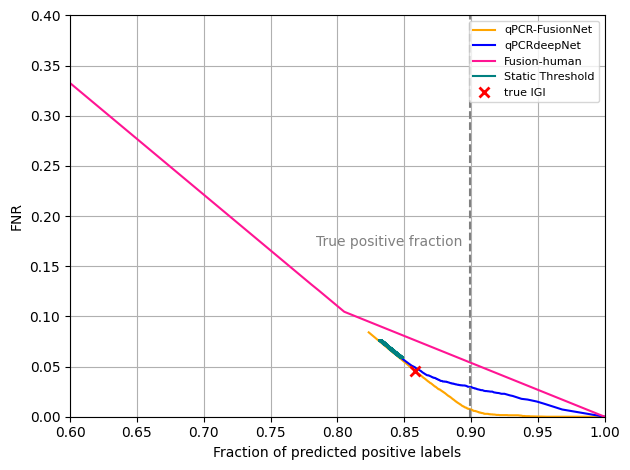

In [174]:
color_map = {'igi': '#008080',
             'fusion': '#ffa500',
             'qpcr':'#00ff00',
             'deepnet': '#0000ff',
             'humanbased': '#ff1493'
             }

plt.plot(model_dict_df.pos_frac, model_dict_df.fnr, color=color_map.get('fusion'), label='qPCR-FusionNet')

# plt.plot(qpcr_model_dict_df.pos_frac, qpcr_model_dict_df.fnr, color=color_map.get('qpcr'), label='qpcR')

plt.plot(deepnet_model_dict_df.pos_frac, deepnet_model_dict_df.fnr, color=color_map.get('deepnet'), label='qPCRdeepNet')

plt.plot(humanbased_model_dict_df.pos_frac, humanbased_model_dict_df.fnr, color=color_map.get('humanbased'), label='Fusion-human')

plt.plot(results_df.positive_rate, 
          results_df.fnr, color=color_map.get('igi'), label='Static Threshold')


# plt.plot(final_thres_df.pos_pred, 
#          final_thres_df.fnr, color=color_map.get('igi'), label='IGI simulation')

plt.plot(igi_pos_frac, igi_fnr, 'x', color='red', **{'ms':7,'mew':2}, label='true IGI')
plt.axvline(true_pos_frac, linestyle='--', color='gray')
plt.text(x=true_pos_frac - 0.115, y = 0.17, s='True positive fraction', c='gray')
plt.xlim(0.6, 1.0)
plt.ylim(0.0,0.4)
plt.xlabel('Fraction of predicted positive labels')
plt.ylabel('FNR')
plt.legend(loc='upper right',fontsize=8)
plt.grid()
# plt.title('FNR of different methods when varying thresholds on test set')
plt.tight_layout()
plt.savefig('fnr_igi_test.png')

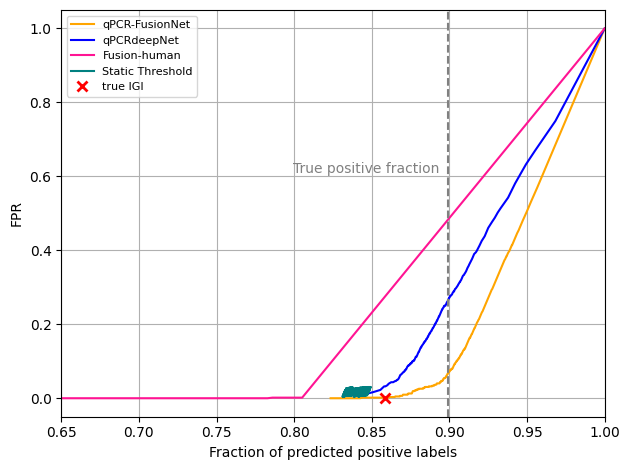

In [175]:
plt.plot(model_dict_df.pos_frac, model_dict_df.fpr, color=color_map.get('fusion'), label='qPCR-FusionNet')

#plt.plot(qpcr_model_dict_df.pos_frac, qpcr_model_dict_df.fpr, color=color_map.get('qpcr'), label='qpcR')

plt.plot(deepnet_model_dict_df.pos_frac, deepnet_model_dict_df.fpr, color=color_map.get('deepnet'), label='qPCRdeepNet')

plt.plot(humanbased_model_dict_df.pos_frac, humanbased_model_dict_df.fpr, color=color_map.get('humanbased'), label='Fusion-human')

# plt.plot(final_thres_df.pos_pred, 
#          final_thres_df.fpr, color=color_map.get('igi'), label='IGI simulation')

plt.plot(results_df.positive_rate, 
          results_df.fpr, color=color_map.get('igi'), label='Static Threshold')

plt.plot(igi_pos_frac, igi_fpr, 'x', color='red', **{'ms':7,'mew':2}, label='true IGI')

plt.axvline(true_pos_frac, linestyle='--', color='gray')
plt.text(x=true_pos_frac - 0.1, y = 0.61, s='True positive fraction', c='gray')
plt.xlim(0.65, 1.0)
# plt.ylim(-0.025,0.15)
plt.xlabel('Fraction of predicted positive labels')
plt.ylabel('FPR')
plt.legend(loc='upper left',fontsize=8)
plt.grid()
plt.tight_layout()
# plt.title('FPR of different methods when varying thresholds on test set')
plt.savefig('fpr_igi_test.png')

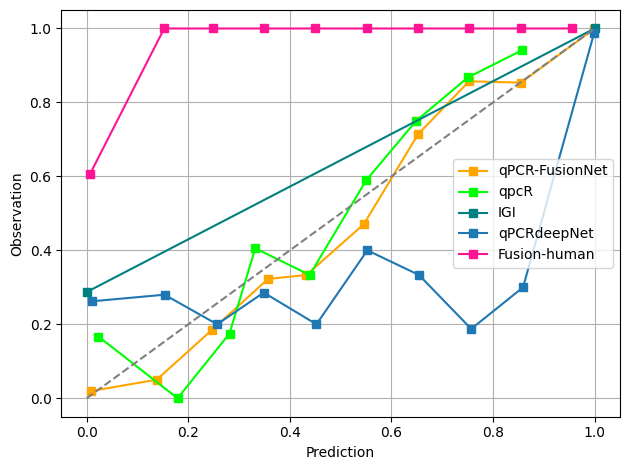

In [94]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(test_pred.groundtruth, test_pred.outputs, n_bins=10)
plt.plot(prob_pred, prob_true, marker='s', linestyle='-', color=color_map.get('fusion'), label='qPCR-FusionNet')

prob_true, prob_pred = calibration_curve(qpcr_test_pred.groundtruth_label, qpcr_test_pred.prob, n_bins=10)
plt.plot(prob_pred, prob_true, marker='s', linestyle='-', color=color_map.get('qpcr'), label='qpcR')

prob_true, prob_pred = calibration_curve(test_pred.groundtruth, test_pred.encoded_igi_call, n_bins=10)
plt.plot(prob_pred, prob_true, marker='s', linestyle='-', color=color_map.get('igi'), label='IGI')

prob_true, prob_pred = calibration_curve(test_qpcrdeepnet.groundtruth_target, test_qpcrdeepnet.prob, n_bins=10)
plt.plot(prob_pred, prob_true, marker='s', linestyle='-', color=color_map.get('qpcrdeepnet'), label='qPCRdeepNet')

prob_true, prob_pred = calibration_curve(humanbased_test.groundtruth_label, humanbased_test.outputs, n_bins=10)
plt.plot(prob_pred, prob_true, marker='s', linestyle='-', color=color_map.get('humanbased'), label='Fusion-human')

plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.grid()
plt.xlabel('Prediction')
plt.ylabel('Observation')
plt.legend()
plt.tight_layout()
plt.savefig('calibration_test.png')

In [ ]:
# final_thres_df.to_csv('/media/ssd1/huong/PCR-huong/data/paper_plots/paper_plots_test_final_thres_df.csv', index=False)

#### retest

In [ ]:
full_retest_pred = (retest_pred
                  .merge(join_df[['curve_idx','threshold','pcr_plate','thres_ct','cycle_no','drn']], #'test_kit',
                         on = 'curve_idx'))
# full_retest_pred['encoded_igi_call'] = 1*(full_retest_pred.igi_call == 'Positive')
print(full_retest_pred.shape)

(39540, 16)


In [ ]:
true_retest_pos_frac = sum(retest_pred.groundtruth_label==1)/retest_pred.shape[0]
print('True retest positive fraction:', true_retest_pos_frac)


True retest positive fraction: 0.35964912280701755


In [ ]:
retest_thres_ct_df = full_retest_pred.loc[full_retest_pred.thres_ct != 'Undetermined', ['curve_idx','thres_ct']].drop_duplicates()
retest_thres_ct_df['cycle_no'] = retest_thres_ct_df.thres_ct.apply(lambda x: np.around(float(x)))

retest_new_thres_df = (full_retest_pred[['pcr_plate','target','curve_idx','cycle_no','drn']]
                  .merge(retest_thres_ct_df, on=['curve_idx','cycle_no']))
retest_new_thres_df['igi_threshold'] = retest_new_thres_df.groupby(['pcr_plate','target']).drn.transform('mean')

full_retest_pred = (full_retest_pred
                  .merge(retest_new_thres_df[['curve_idx','igi_threshold']], on =['curve_idx'], how='left')
                  )


full_retest_pred.loc[full_retest_pred.igi_threshold.isna(),'igi_threshold'] = full_retest_pred.loc[full_retest_pred.igi_threshold.isna(),'threshold']
print(full_retest_pred.shape)
full_retest_pred.head(5)

(39540, 17)


,curve_idx,outputs,igi_fp,igi_fn,target,sample_id,groundtruth_label,igi_call,encoded_igi_call,test_kit,pred,threshold,pcr_plate,thres_ct,cycle_no,drn,igi_threshold
0,108884,0.000376,7.229704e-09,0.000303,E gene,S1160529,0.0,Negative,0,LuNER,0,6000.0,AC00H0VO,Undetermined,1,-1869.934593,6000.0
1,108884,0.000376,7.229704e-09,0.000303,E gene,S1160529,0.0,Negative,0,LuNER,0,6000.0,AC00H0VO,Undetermined,2,-1922.696429,6000.0
2,108884,0.000376,7.229704e-09,0.000303,E gene,S1160529,0.0,Negative,0,LuNER,0,6000.0,AC00H0VO,Undetermined,3,-1456.583264,6000.0
3,108884,0.000376,7.229704e-09,0.000303,E gene,S1160529,0.0,Negative,0,LuNER,0,6000.0,AC00H0VO,Undetermined,4,-844.782600,6000.0
4,108884,0.000376,7.229704e-09,0.000303,E gene,S1160529,0.0,Negative,0,LuNER,0,6000.0,AC00H0VO,Undetermined,5,-579.200685,6000.0


In [ ]:
retest_plate_target_pair = full_retest_pred[['pcr_plate','target','test_kit']].drop_duplicates()


### systematically move Fn thresholds

In [ ]:
retest_thres_df = {'fpr':[], 'fnr':[], 'pos_pred': []}

for perc in fn_range:
    for cycle in range(10):
        df = full_retest_pred.copy()
        df['new_threshold'] = df.igi_threshold * (1 + perc)
        
        df['if_pass'] = df.drn >= df.new_threshold
        passed_ids = df[df.if_pass].curve_idx.unique()
        df['new_ct'] = np.Inf
        df.loc[df.curve_idx.isin(passed_ids), 'new_ct'] = df[df.curve_idx.isin(passed_ids)].groupby('curve_idx').cycle_no.transform('min')
        
        
        # if df.test_kit.iloc[0] == 'Thermo':
        df.loc[df.test_kit == 'Thermo','new_igi_call'] = 1*(df[df.test_kit == 'Thermo'].new_ct <= cycle_range_dict['Thermo'][cycle])
    
        df.loc[(df.test_kit == 'LuNER') & (df.target == 'RnaseP'), 'new_igi_call'] = 1*(df[(df.test_kit == 'LuNER') & (df.target == 'RnaseP')].new_ct <= cycle_range_dict['LuNER']['RnaseP'][cycle])
        df.loc[(df.test_kit == 'LuNER') & (df.target != 'RnaseP'), 'new_igi_call'] = 1*(df[(df.test_kit == 'LuNER') & (df.target != 'RnaseP')].new_ct <= cycle_range_dict['LuNER']['other'][cycle])
        
        df_1 = df[df.cycle_no == 1]
        tn, fp, fn, tp = confusion_matrix(df_1.groundtruth_label, df_1.new_igi_call, labels=np.array([0,1])).ravel()
        
        retest_thres_df['fpr'].append(fp/(fp+tn))
        retest_thres_df['fnr'].append(fn/(fn+tp))
        retest_thres_df['pos_pred'].append((fp+tp)/(fp+tp+tn+fn))
        
        

In [ ]:
retest_final_thres_df = pd.DataFrame(retest_thres_df)
retest_final_thres_df['fpr_type'] = 'simulated'
retest_final_thres_df['fnr_type'] = 'simulated'


In [ ]:
igi_tn, igi_fp, igi_fn, igi_tp = confusion_matrix(retest_pred.groundtruth_label, retest_pred.encoded_igi_call, labels=np.array([0,1])).ravel()
retest_igi_fnr = igi_fn/(igi_fn+igi_tp) 
retest_igi_pos_frac = (igi_fp + igi_tp)/(igi_fp+igi_tp+igi_fn+igi_tn)
retest_igi_fpr = igi_fp/(igi_fp + igi_tn)

In [ ]:
true_retest_pos_frac = sum(retest_pred.groundtruth_label == 1)/retest_pred.shape[0]

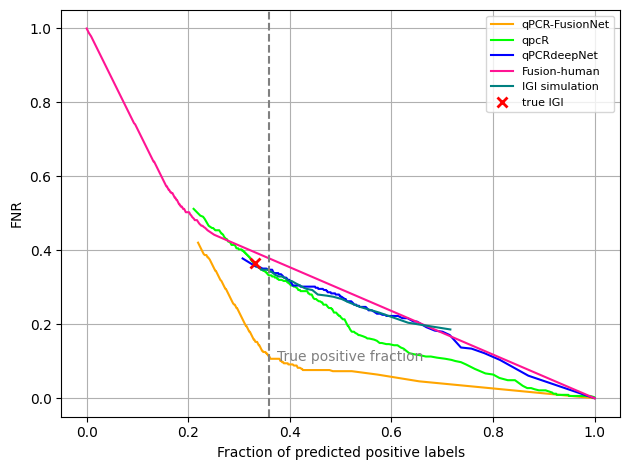

In [ ]:

# plt.plot(retest_final_thres_df.pos_pred, 
#          retest_final_thres_df.fnr, 
#          '.', **{'mfc': 'none', 'mec':'blue','mew':0.5}, label='IGI simulation')

# plt.plot(retest_igi_pos_frac, retest_igi_fnr, 'x', color='red', **{'ms':7,'mew':2}, label='true IGI')

# plt.plot(retest_model_dict_df.pos_frac, retest_model_dict_df.fnr, color='green', label='Model')
# plt.plot(qpcr_model_retest_dict_df.pos_frac, qpcr_model_retest_dict_df.fnr, color='orange', label='qpcR')


plt.plot(retest_model_dict_df.pos_frac, retest_model_dict_df.fnr, color=color_map.get('fusion'), label='qPCR-FusionNet')

plt.plot(qpcr_model_retest_dict_df.pos_frac, qpcr_model_retest_dict_df.fnr, color=color_map.get('qpcr'), label='qpcR')

plt.plot(deepnet_model_retest_dict_df.pos_frac, deepnet_model_retest_dict_df.fnr, color=color_map.get('deepnet'), label='qPCRdeepNet')

plt.plot(humanbased_model_retest_dict_df.pos_frac, humanbased_model_retest_dict_df.fnr, color=color_map.get('humanbased'), label='Fusion-human')

plt.plot(retest_final_thres_df.pos_pred, 
         retest_final_thres_df.fnr, color=color_map.get('igi'), label='IGI simulation')
plt.plot(retest_igi_pos_frac, retest_igi_fnr, 'x', color='red', **{'ms':7,'mew':2}, label='true IGI')


plt.axvline(true_retest_pos_frac, linestyle='--', color='gray')
plt.text(x=true_retest_pos_frac + 0.015, y = 0.1, s='True positive fraction', c='grey')
# plt.xlim(0., 0.6)
# plt.ylim(0.05, 1.)
plt.xlabel('Fraction of predicted positive labels')
plt.ylabel('FNR')
plt.legend(loc='upper right',fontsize=8)
plt.grid()
plt.tight_layout()
# plt.title('FNR of different methods when varying thresholds on Retest set')
plt.savefig('/home/alpaca/Documents/huong/PCR-huong/PCR_simulation/evaluation/paper_plots/figures/fnr_igi_retest.png')

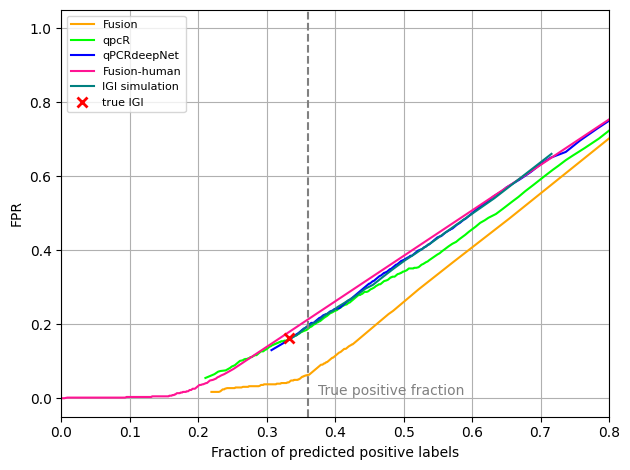

In [ ]:


plt.plot(retest_model_dict_df.pos_frac, retest_model_dict_df.fpr, color=color_map.get('fusion'), label='Fusion')

plt.plot(qpcr_model_retest_dict_df.pos_frac, qpcr_model_retest_dict_df.fpr, color=color_map.get('qpcr'), label='qpcR')

plt.plot(deepnet_model_retest_dict_df.pos_frac, deepnet_model_retest_dict_df.fpr, color=color_map.get('deepnet'), label='qPCRdeepNet')

plt.plot(humanbased_model_retest_dict_df.pos_frac, humanbased_model_retest_dict_df.fpr, color=color_map.get('humanbased'), label='Fusion-human')

plt.plot(retest_final_thres_df.pos_pred, 
         retest_final_thres_df.fpr, color=color_map.get('igi'), label='IGI simulation')
plt.plot(retest_igi_pos_frac, retest_igi_fpr, 'x', color='red', **{'ms':7,'mew':2}, label='true IGI')


plt.axvline(true_retest_pos_frac, linestyle='--', color='gray')
plt.text(x=true_retest_pos_frac + 0.015, y = 0.01, s='True positive fraction', c='grey')
plt.xlim(0., 0.8)
# plt.ylim(0,0.6)
plt.xlabel('Fraction of predicted positive labels')
plt.ylabel('FPR')
plt.legend(loc='upper left',fontsize=8)
plt.grid()
plt.tight_layout()
# plt.title('FPR of different methods when varying thresholds on Retest')
plt.savefig('/home/alpaca/Documents/huong/PCR-huong/PCR_simulation/evaluation/paper_plots/figures/fpr_igi_retest.png')

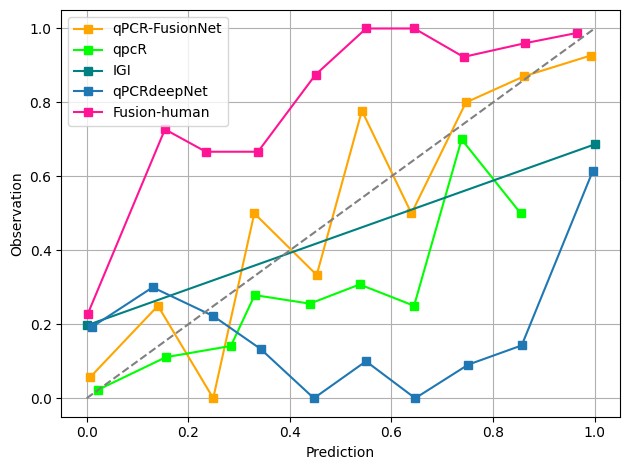

In [ ]:

prob_true, prob_pred = calibration_curve(retest_pred.groundtruth_label, retest_pred.outputs, n_bins=10)
plt.plot(prob_pred, prob_true, marker='s', linestyle='-', color=color_map.get('fusion'), label='qPCR-FusionNet')

prob_true, prob_pred = calibration_curve(qpcr_retest_pred.groundtruth_label, qpcr_retest_pred.prob, n_bins=10)
plt.plot(prob_pred, prob_true, marker='s', linestyle='-', color=color_map.get('qpcr'), label='qpcR')

prob_true, prob_pred = calibration_curve(retest_pred.groundtruth_label, retest_pred.encoded_igi_call, n_bins=10)
plt.plot(prob_pred, prob_true, marker='s', linestyle='-', color=color_map.get('igi'), label='IGI')

prob_true, prob_pred = calibration_curve(retest_qpcrdeepnet.groundtruth_label, retest_qpcrdeepnet.prob, n_bins=10)
plt.plot(prob_pred, prob_true, marker='s', linestyle='-', color=color_map.get('qpcrdeepnet'), label='qPCRdeepNet')

prob_true, prob_pred = calibration_curve(humanbased_retest.groundtruth_label, humanbased_retest.outputs, n_bins=10)
plt.plot(prob_pred, prob_true, marker='s', linestyle='-', color=color_map.get('humanbased'), label='Fusion-human')

plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.grid()
plt.xlabel('Prediction')
plt.ylabel('Observation')
plt.legend()
plt.tight_layout()
plt.savefig('/home/alpaca/Documents/huong/PCR-huong/PCR_simulation/evaluation/paper_plots/figures/calibration_retest.png')

In [ ]:
retest_final_thres_df.to_csv('/media/ssd1/huong/PCR-huong/data/paper_plots/paper_plots_retest_final_thres_df.csv', index=False)